# Prediksi Kondisi Nilai Tukar Rupiah terhadap Dolar AS dalam 30 Hari ke Depan

**Pendekatan:** Regression-to-Classification — prediksi return (regresi) lalu konversi ke kelas via threshold asymmetric.

| Label | Kondisi | Definisi |
|-------|---------|----------|
| 0 | 💹 Menguat | USD/IDR turun > threshold (Rupiah apresiasi) |
| 1 | ➡️ Stabil | USD/IDR bergerak dalam rentang threshold |
| 2 | 📉 Melemah | USD/IDR naik > threshold (Rupiah depresiasi) |

- **Dataset:** `rupiah_dataset_fixed.csv`
- **Model:** GradientBoostingRegressor + XGBoost Ensemble (Base Model, tanpa hyperparameter tuning eksternal)
- **Periode Data:** Juli 2007 – Mei 2026


## 1. Import Library & Setup

In [36]:
# ── Standard library ────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# ── Third-party: data & numerics ────────────────────────────
import numpy as np
import pandas as pd

# ── Third-party: visualization ──────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

# ── Third-party: ML — preprocessing & evaluation ────────────
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)

# ── Third-party: ML — models ────────────────────────────────
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor
)
from xgboost import XGBRegressor
import shap

# ────────────────────────────────────────────────────────────
# GLOBAL CONFIGURATION
# ────────────────────────────────────────────────────────────
RANDOM_STATE   = 42
DATA_PATH      = "rupiah_dataset_fixed.csv"
HORIZON        = 30          # hari ke depan yang diprediksi
THRESHOLD      = 1.0         # threshold awal labeling target (±%)

# Threshold grid untuk tuning asymmetric
LOWER_GRID = np.round(np.arange(-2.0, -0.2, 0.05), 2)
UPPER_GRID = np.round(np.arange(0.2, 2.1, 0.05), 2)

# Plot style global
plt.rcParams["figure.figsize"]      = (12, 5)
plt.rcParams["axes.grid"]           = True
plt.rcParams["grid.alpha"]          = 0.3
plt.rcParams["axes.spines.top"]     = False
plt.rcParams["axes.spines.right"]   = False

np.random.seed(RANDOM_STATE)

# Verifikasi versi library
import xgboost as xgb
print("Library berhasil diimport.")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
print(f"  xgboost : {xgb.__version__}")


Library berhasil diimport.
  pandas  : 3.0.2
  numpy   : 2.4.2
  xgboost : 3.2.0


## 2. Load & Analisis Awal Dataset

### 2.1 Load Data

In [37]:
df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print(f"Shape   : {df.shape}")
print(f"Kolom   : {df.columns.tolist()}")
print(f"Rentang : {df['Date'].min().date()} hingga {df['Date'].max().date()}")
print(f"Total hari perdagangan: {len(df):,} baris")
df.head(10)


Shape   : (4881, 14)
Kolom   : ['Date', 'USDIDR', 'DXY', 'BRENT', 'GOLD', 'VIX', 'IHSG', 'US10Y', 'SP500', 'FED_RATE', 'TRADE_BALANCE', 'FX_RESERVE', 'BI_Rate', 'M2_ID']
Rentang : 2007-07-30 hingga 2026-05-29
Total hari perdagangan: 4,881 baris


,Date,USDIDR,DXY,BRENT,GOLD,VIX,IHSG,US10Y,SP500,FED_RATE,TRADE_BALANCE,FX_RESERVE,BI_Rate,M2_ID
0,2007-07-30,9187.099609,80.849998,75.739998,664.099976,20.870001,2301.462646,4.804,1473.910034,5.25,3.542400e+09,49405.545762,8.0,1.454577e+15
1,2007-07-31,9213.599609,80.769997,77.050003,666.900024,23.520000,2348.581543,4.771,1455.270020,5.25,3.542400e+09,49405.545762,8.0,1.454577e+15
2,2007-08-01,9294.000000,80.870003,75.349998,663.599976,23.670000,2256.220459,4.759,1465.810059,5.02,2.678800e+09,49863.603315,8.0,1.493050e+15
3,2007-08-02,9273.599609,80.709999,75.760002,664.599976,21.219999,2270.765625,4.753,1472.199951,5.02,2.678800e+09,49863.603315,8.0,1.493050e+15
4,2007-08-03,9220.799805,80.180000,74.750000,672.500000,25.160000,2269.702637,4.700,1433.060059,5.02,2.678800e+09,49863.603315,8.0,1.493050e+15
5,2007-08-06,9213.099609,80.250000,71.169998,671.500000,22.940001,2189.021484,4.731,1467.670044,5.02,2.678800e+09,49863.603315,8.0,1.493050e+15
6,2007-08-07,9250.000000,80.480003,71.800003,670.599976,21.559999,2173.986328,4.743,1476.709961,5.02,2.678800e+09,49863.603315,8.0,1.493050e+15
7,2007-08-08,9209.099609,80.339996,70.989998,674.500000,21.450001,2262.547852,4.860,1497.489990,5.02,2.678800e+09,49863.603315,8.0,1.493050e+15
8,2007-08-09,9296.000000,80.739998,70.209999,661.400024,26.480000,2241.314941,4.790,1453.089966,5.02,2.678800e+09,49863.603315,8.0,1.493050e+15
9,2007-08-10,9286.900391,80.680000,70.389999,670.299988,28.299999,2207.310059,4.776,1453.640015,5.02,2.678800e+09,49863.603315,8.0,1.493050e+15


### 2.2 Tipe Data & Missing Values

In [38]:
def show_data_info(df: pd.DataFrame) -> None:
    """Cetak ringkasan tipe data dan jumlah missing value per kolom."""
    print("=" * 55)
    print(f"{'Kolom':<15} {'Tipe':>10} {'Non-Null':>10} {'Missing':>10}")
    print("=" * 55)
    for col in df.columns:
        non_null = df[col].notna().sum()
        missing  = df[col].isna().sum()
        dtype    = str(df[col].dtype)
        print(f"{col:<15} {dtype:>10} {non_null:>10} {missing:>10}")
    print("=" * 55)

show_data_info(df)
print()
print("Kesimpulan: Tidak ada missing value pada dataset mentah.")
print("Namun perlu dilakukan pengecekan anomali data secara lebih dalam.")


Kolom                 Tipe   Non-Null    Missing
Date            datetime64[us]       4881          0
USDIDR             float64       4881          0
DXY                float64       4881          0
BRENT              float64       4881          0
GOLD               float64       4881          0
VIX                float64       4881          0
IHSG               float64       4881          0
US10Y              float64       4881          0
SP500              float64       4881          0
FED_RATE           float64       4881          0
TRADE_BALANCE      float64       4881          0
FX_RESERVE         float64       4881          0
BI_Rate            float64       4881          0
M2_ID              float64       4881          0

Kesimpulan: Tidak ada missing value pada dataset mentah.
Namun perlu dilakukan pengecekan anomali data secara lebih dalam.


### 2.3 Statistik Deskriptif

In [39]:
df.describe().round(2)


,Date,USDIDR,DXY,BRENT,GOLD,VIX,IHSG,US10Y,SP500,FED_RATE,TRADE_BALANCE,FX_RESERVE,BI_Rate,M2_ID
count,4881,4881.00,4881.00,4881.00,4881.00,4881.00,4881.00,4881.00,4881.00,4881.00,4.881000e+03,4881.00,4881.00,4.881000e+03
mean,2017-01-09 03:22:40.786724,12746.66,91.11,78.21,1633.70,19.96,5146.21,2.77,2807.48,1.52,1.508664e+09,110064.43,5.96,5.210779e+15
min,2007-07-30 00:00:00,888.11,71.33,19.33,648.30,9.14,1111.35,0.50,676.53,0.05,-2.331100e+09,48773.30,3.50,1.454577e+15
25%,2012-05-04 00:00:00,9683.40,80.80,61.28,1220.20,14.18,4026.32,1.96,1416.18,0.11,1.588000e+08,101274.08,4.75,2.994474e+15
50%,2017-01-10 00:00:00,13388.00,93.83,75.58,1384.00,17.63,5254.36,2.65,2269.00,0.36,1.200900e+09,114115.25,6.00,4.942920e+15
75%,2021-09-17 00:00:00,14620.00,98.63,98.27,1811.40,22.94,6500.53,3.66,3965.34,2.56,2.665400e+09,130864.37,6.75,7.300921e+15
max,2026-05-29 00:00:00,17878.00,114.11,146.08,5318.40,82.69,9134.70,4.99,7580.06,5.33,7.558700e+09,144531.06,9.25,1.035511e+16
std,NaN,2574.61,10.01,23.76,759.11,8.77,1702.64,1.03,1624.94,1.83,1.822896e+09,27103.51,1.45,2.555702e+15


### 2.4 Karakteristik Time Series

Data ini adalah **data harian perdagangan forex** (weekday only), sehingga:
- Tidak ada data akhir pekan (Sabtu & Minggu)
- Ada gap pada hari libur nasional Indonesia maupun internasional
- Frekuensi tidak benar-benar seragam — perlu diperhatikan saat membuat fitur rolling window


In [40]:
def analyze_time_gaps(df: pd.DataFrame) -> pd.DataFrame:
    """
    Analisis distribusi hari perdagangan dan gap antar tanggal.

    Returns
    -------
    df dengan kolom 'date_diff' ditambahkan (sementara, di-drop setelah cleaning).
    """
    df = df.copy()
    dow_counts = df["Date"].dt.dayofweek.value_counts().sort_index()
    dow_names  = ["Senin", "Selasa", "Rabu", "Kamis", "Jumat"]

    print("Distribusi Hari Perdagangan:")
    for i, name in enumerate(dow_names):
        print(f"  {name:<8}: {dow_counts.get(i, 0):>4} hari")
    print()

    df["date_diff"] = df["Date"].diff().dt.days
    print("Statistik jarak antar tanggal (hari):")
    print(df["date_diff"].describe().round(1))
    print()

    large_gaps = df[df["date_diff"] > 5][["Date", "date_diff"]].copy()
    large_gaps["Keterangan"] = "Gap besar karena libur panjang / market tutup"
    print(f"Gap besar (>5 hari): {len(large_gaps)} kejadian")
    print(large_gaps.to_string(index=False))
    return df

df = analyze_time_gaps(df)


Distribusi Hari Perdagangan:
  Senin   :  976 hari
  Selasa  :  974 hari
  Rabu    :  978 hari
  Kamis   :  976 hari
  Jumat   :  977 hari

Statistik jarak antar tanggal (hari):
count    4880.0
mean        1.4
std         0.9
min         1.0
25%         1.0
50%         1.0
75%         1.0
max        26.0
Name: date_diff, dtype: float64

Gap besar (>5 hari): 1 kejadian
      Date  date_diff                                    Keterangan
2008-08-26       26.0 Gap besar karena libur panjang / market tutup


### 2.5 Deteksi Anomali Data

Dari pengecekan awal, ditemukan 2 baris dengan nilai USDIDR yang sangat tidak wajar (~888 dan ~892),
padahal secara historis nilai terendah USD/IDR sekitar tahun 2010–2012 ada di kisaran 8.500–9.500.

Nilai tersebut kemungkinan besar adalah **data entry error** (satuan terbalik / divided by 10).


In [41]:
def show_anomalies(df: pd.DataFrame, threshold: float = 5000) -> None:
    """Tampilkan baris dengan nilai USDIDR di bawah threshold dan konteks sekitarnya."""
    anomali = df[df["USDIDR"] < threshold][["Date", "USDIDR", "DXY", "BRENT", "GOLD", "VIX"]]
    print(f"Baris dengan nilai USDIDR anomali (<{threshold:,}):")
    print(anomali.to_string(index=False))
    print()

    if not anomali.empty:
        idx = anomali.index[0]
        print(f"Konteks baris sekitar anomali {df.loc[idx, 'Date'].date()}:")
        print(df.loc[idx - 2 : idx + 2, ["Date", "USDIDR"]].to_string(index=False))
        print()
        print("=> Nilai 888 dan 892 jelas tidak realistis.")
        print("   Nilai seharusnya sekitar 8.880 dan 8.920 (kemungkinan data entry error).")
        print("   Solusi: replace dengan NaN lalu forward-fill dari baris sebelumnya.")

show_anomalies(df)


Baris dengan nilai USDIDR anomali (<5,000):
      Date     USDIDR       DXY      BRENT        GOLD   VIX
2010-11-01 888.109985 77.300003  84.620003 1350.199951 21.83
2012-02-07 892.000000 78.570000 116.230003 1746.400024 17.65

Konteks baris sekitar anomali 2010-11-01:
      Date      USDIDR
2010-10-28 8923.799805
2010-10-29 8923.799805
2010-11-01  888.109985
2010-11-02 8906.700195
2010-11-03 8827.900391

=> Nilai 888 dan 892 jelas tidak realistis.
   Nilai seharusnya sekitar 8.880 dan 8.920 (kemungkinan data entry error).
   Solusi: replace dengan NaN lalu forward-fill dari baris sebelumnya.


## 3. Data Cleaning

### Keputusan Cleaning:
1. **Anomali USDIDR** → Replace dengan NaN, lalu forward-fill
2. **Kolom `date_diff`** → Drop (kolom sementara dari analisis)
3. **Duplicate dates** → Tidak ditemukan (sudah terverifikasi)


In [42]:
def clean_data(df: pd.DataFrame, usdidr_min: float = 5000) -> pd.DataFrame:
    """
    Bersihkan dataset dari anomali USDIDR dan kolom sementara.

    Parameters
    ----------
    df         : DataFrame mentah hasil load + analyze_time_gaps
    usdidr_min : Nilai minimum yang dianggap valid untuk USDIDR

    Returns
    -------
    df_clean : DataFrame yang sudah dibersihkan
    """
    df_clean = df.copy()

    # Perbaiki anomali USDIDR dengan forward-fill
    df_clean.loc[df_clean["USDIDR"] < usdidr_min, "USDIDR"] = np.nan
    df_clean["USDIDR"] = df_clean["USDIDR"].ffill()

    # Hapus kolom sementara
    df_clean = df_clean.drop(columns=["date_diff"], errors="ignore")

    return df_clean


df_clean = clean_data(df)

print("Setelah cleaning:")
print(f"  Shape      : {df_clean.shape}")
print(f"  Missing    : {df_clean.isnull().sum().sum()}")
print(f"  USDIDR min : {df_clean['USDIDR'].min():.1f}")
print(f"  USDIDR max : {df_clean['USDIDR'].max():.1f}")
print()
print("Data cleaning selesai. Dataset siap untuk EDA.")


Setelah cleaning:
  Shape      : (4881, 14)
  Missing    : 0
  USDIDR min : 8292.7
  USDIDR max : 17878.0

Data cleaning selesai. Dataset siap untuk EDA.


## 4. Exploratory Data Analysis (EDA)

### 4.1 Tren USDIDR Sepanjang Waktu

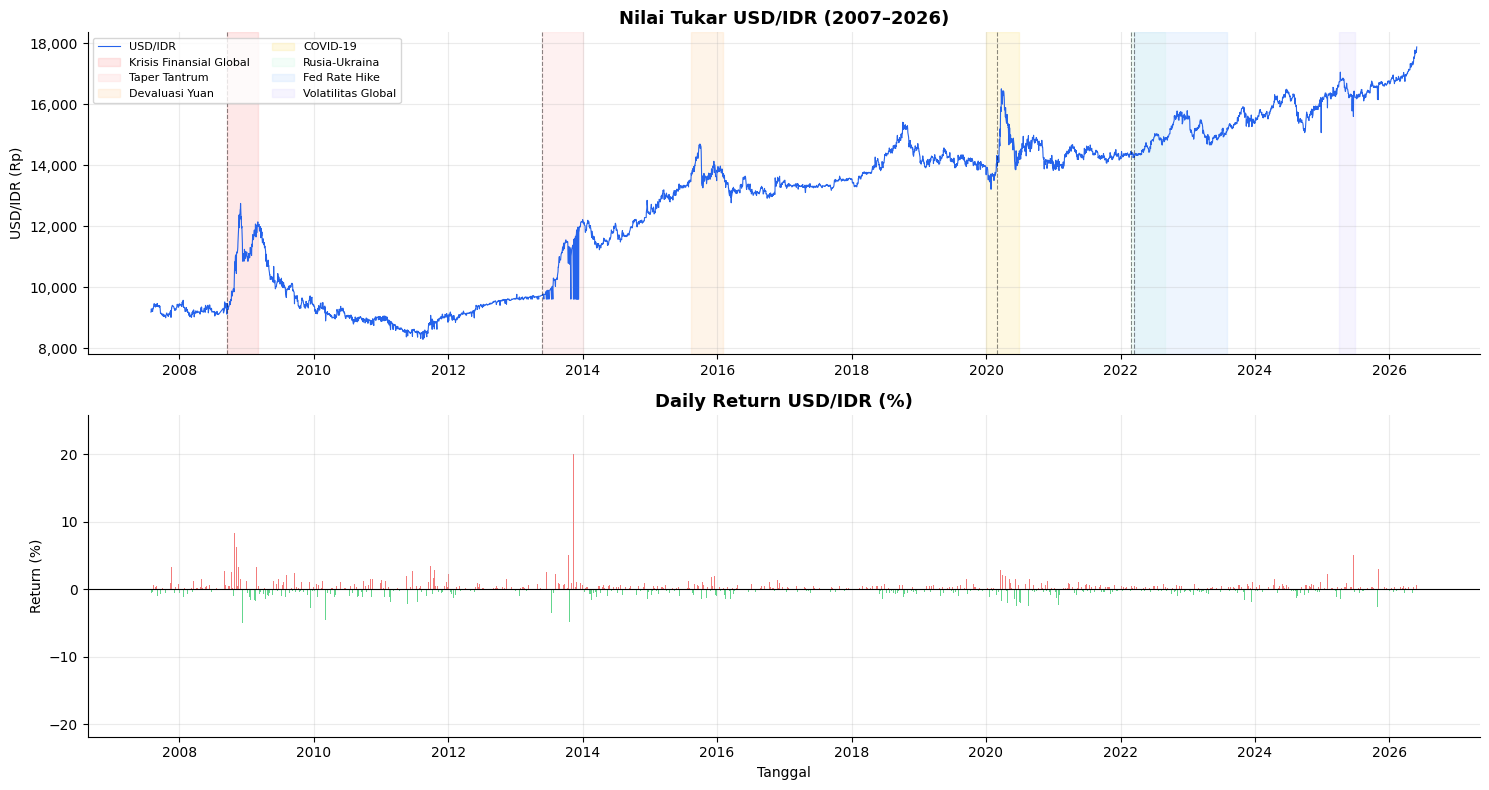

Insight:
- USD/IDR menunjukkan tren naik jangka panjang (depresiasi Rupiah struktural).
- Volatilitas meningkat pada periode Krisis 2008, Taper Tantrum, COVID-19, dan Fed Rate Hike.
- Temuan ini mendukung penggunaan DXY, FED_RATE, BI_Rate, rate_diff, IHSG, US10Y, VIX.


In [43]:
# Event makroekonomi penting untuk anotasi
MACRO_EVENTS = [
    ("2008-09-15", "2009-03-01", "#fca5a5", "Krisis Finansial Global"),
    ("2013-05-22", "2013-12-31", "#fecaca", "Taper Tantrum"),
    ("2015-08-11", "2016-02-01", "#fed7aa", "Devaluasi Yuan"),
    ("2020-01-01", "2020-06-30", "#fde68a", "COVID-19"),
    ("2022-02-24", "2022-09-01", "#d1fae5", "Rusia-Ukraina"),
    ("2022-03-16", "2023-07-31", "#bfdbfe", "Fed Rate Hike"),
    ("2025-04-01", "2025-06-30", "#ddd6fe", "Volatilitas Global"),
]

IMPORTANT_DATES = [
    ("2008-09-15", "Lehman"),
    ("2013-05-22", "Taper"),
    ("2020-03-02", "COVID ID"),
    ("2022-02-24", "War"),
    ("2022-03-16", "Fed Hike"),
]


def plot_usdidr_trend(df_clean: pd.DataFrame) -> None:
    """Plot tren USD/IDR dan daily return beserta anotasi event makro."""
    df_clean = df_clean.copy()
    df_clean["return_1d"] = df_clean["USDIDR"].pct_change() * 100

    fig, axes = plt.subplots(2, 1, figsize=(15, 8))

    # -- Panel atas: USD/IDR time series + event shading
    axes[0].plot(df_clean["Date"], df_clean["USDIDR"],
                 color="#2563eb", linewidth=0.8, label="USD/IDR")
    axes[0].set_title("Nilai Tukar USD/IDR (2007–2026)", fontsize=13, fontweight="bold")
    axes[0].set_ylabel("USD/IDR (Rp)")
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    for start, end, color, label in MACRO_EVENTS:
        axes[0].axvspan(pd.Timestamp(start), pd.Timestamp(end),
                        alpha=0.25, color=color, label=label)

    for date, label in IMPORTANT_DATES:
        axes[0].axvline(pd.Timestamp(date), color="black",
                        linestyle="--", alpha=0.45, linewidth=0.8)

    axes[0].legend(fontsize=8, ncol=2, loc="upper left")
    axes[0].grid(alpha=0.25)

    # -- Panel bawah: daily return bar chart
    axes[1].bar(
        df_clean["Date"],
        df_clean["return_1d"],
        color=np.where(df_clean["return_1d"] > 0, "#ef4444", "#22c55e"),
        width=1,
        alpha=0.7,
    )
    axes[1].set_title("Daily Return USD/IDR (%)", fontsize=13, fontweight="bold")
    axes[1].set_ylabel("Return (%)")
    axes[1].set_xlabel("Tanggal")
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    print("Insight:")
    print("- USD/IDR menunjukkan tren naik jangka panjang (depresiasi Rupiah struktural).")
    print("- Volatilitas meningkat pada periode Krisis 2008, Taper Tantrum, COVID-19, dan Fed Rate Hike.")
    print("- Temuan ini mendukung penggunaan DXY, FED_RATE, BI_Rate, rate_diff, IHSG, US10Y, VIX.")


plot_usdidr_trend(df_clean)


### 4.2 Distribusi Return & Volatilitas

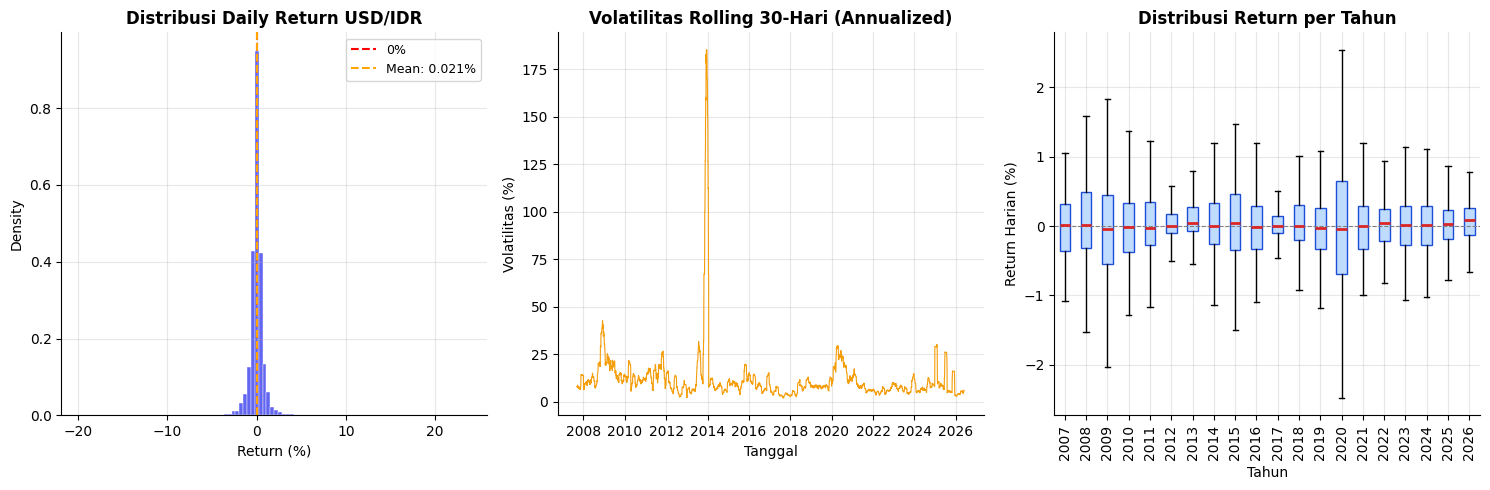

Skewness daily return : 2.8968 (sedikit right-skewed)
Kurtosis daily return : 162.2960 (fat tails / leptokurtic)
=> Distribusi return TIDAK normal — sesuai dengan data keuangan pada umumnya.


In [44]:
def plot_return_distribution(df_clean: pd.DataFrame) -> None:
    """Plot distribusi return harian, volatilitas rolling 30 hari, dan boxplot per tahun."""
    df_clean = df_clean.copy()
    df_clean["return_1d"] = df_clean["USDIDR"].pct_change() * 100
    df_clean["vol_30d"]   = df_clean["return_1d"].rolling(30).std() * np.sqrt(252)
    df_clean["Year"]      = df_clean["Date"].dt.year

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # -- Histogram return harian
    axes[0].hist(df_clean["return_1d"].dropna(), bins=100,
                 color="#6366f1", edgecolor="white", linewidth=0.3, density=True)
    axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5, label="0%")
    axes[0].axvline(df_clean["return_1d"].mean(), color="orange", linestyle="--",
                    linewidth=1.5, label=f"Mean: {df_clean['return_1d'].mean():.3f}%")
    axes[0].set_title("Distribusi Daily Return USD/IDR", fontweight="bold")
    axes[0].set_xlabel("Return (%)")
    axes[0].set_ylabel("Density")
    axes[0].legend(fontsize=9)

    # -- Volatilitas rolling
    axes[1].plot(df_clean["Date"], df_clean["vol_30d"], color="#f59e0b", linewidth=0.8)
    axes[1].set_title("Volatilitas Rolling 30-Hari (Annualized)", fontweight="bold")
    axes[1].set_xlabel("Tanggal")
    axes[1].set_ylabel("Volatilitas (%)")

    # -- Boxplot return per tahun
    years        = sorted(df_clean["Year"].unique())
    data_per_year = [df_clean[df_clean["Year"] == y]["return_1d"].dropna().values for y in years]
    axes[2].boxplot(
        data_per_year,
        labels=years,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(facecolor="#bfdbfe", color="#1d4ed8"),
        medianprops=dict(color="#dc2626", linewidth=2),
    )
    axes[2].set_title("Distribusi Return per Tahun", fontweight="bold")
    axes[2].set_xlabel("Tahun")
    axes[2].set_ylabel("Return Harian (%)")
    axes[2].tick_params(axis="x", rotation=90)
    axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8)

    plt.tight_layout()
    plt.show()

    print(f"Skewness daily return : {df_clean['return_1d'].skew():.4f} (sedikit right-skewed)")
    print(f"Kurtosis daily return : {df_clean['return_1d'].kurt():.4f} (fat tails / leptokurtic)")
    print("=> Distribusi return TIDAK normal — sesuai dengan data keuangan pada umumnya.")


plot_return_distribution(df_clean)


### 4.3 Korelasi Antar Variabel Makroekonomi

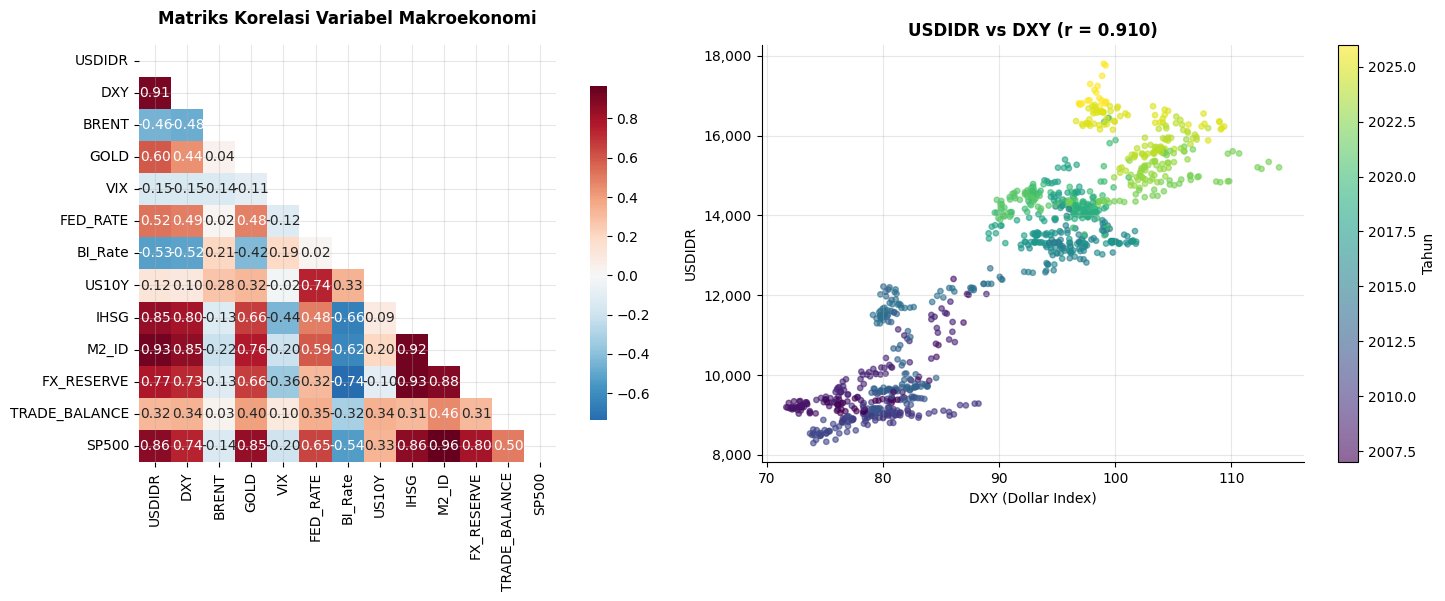

Insight Korelasi:
------------------------------------------------------------
DXY             → USDIDR: r = 0.910 (sangat kuat positif)
BRENT           → USDIDR: r = -0.455 (sedang negatif)
GOLD            → USDIDR: r = 0.595 (sedang positif)
VIX             → USDIDR: r = -0.148 (sangat lemah negatif)
FED_RATE        → USDIDR: r = 0.519 (sedang positif)
BI_Rate         → USDIDR: r = -0.529 (sedang negatif)
US10Y           → USDIDR: r = 0.122 (sangat lemah positif)
IHSG            → USDIDR: r = 0.847 (sangat kuat positif)
M2_ID           → USDIDR: r = 0.930 (sangat kuat positif)
FX_RESERVE      → USDIDR: r = 0.774 (kuat positif)
TRADE_BALANCE   → USDIDR: r = 0.321 (lemah positif)
SP500           → USDIDR: r = 0.865 (sangat kuat positif)


In [45]:
MACRO_COLS = [
    "USDIDR", "DXY", "BRENT", "GOLD", "VIX",
    "FED_RATE", "BI_Rate", "US10Y", "IHSG",
    "M2_ID", "FX_RESERVE", "TRADE_BALANCE", "SP500",
]

CORR_STRENGTH_LABELS = [
    (0.80, "sangat kuat"),
    (0.60, "kuat"),
    (0.40, "sedang"),
    (0.20, "lemah"),
]


def get_corr_label(r: float) -> str:
    """Kembalikan label kekuatan korelasi berdasarkan nilai absolut r."""
    for threshold, label in CORR_STRENGTH_LABELS:
        if abs(r) >= threshold:
            return label
    return "sangat lemah"


def plot_correlation_analysis(df_clean: pd.DataFrame) -> None:
    """Plot heatmap korelasi dan scatter USDIDR vs DXY."""
    corr = df_clean[MACRO_COLS].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # -- Heatmap korelasi
    sns.heatmap(
        corr, mask=mask, annot=True, fmt=".2f",
        cmap="RdBu_r", center=0, square=True,
        ax=axes[0], annot_kws={"size": 10},
        cbar_kws={"shrink": 0.8},
    )
    axes[0].set_title("Matriks Korelasi Variabel Makroekonomi", fontweight="bold", pad=15)

    # -- Scatter USDIDR vs DXY (sample 1000 titik untuk efisiensi visual)
    sample = df_clean.sample(min(1000, len(df_clean)), random_state=RANDOM_STATE)
    scatter = axes[1].scatter(
        sample["DXY"], sample["USDIDR"],
        c=sample["Date"].dt.year, cmap="viridis", alpha=0.6, s=15,
    )
    plt.colorbar(scatter, ax=axes[1], label="Tahun")
    axes[1].set_title(f"USDIDR vs DXY (r = {corr.loc['USDIDR', 'DXY']:.3f})", fontweight="bold")
    axes[1].set_xlabel("DXY (Dollar Index)")
    axes[1].set_ylabel("USDIDR")
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    plt.tight_layout()
    plt.show()

    print("Insight Korelasi:")
    print("-" * 60)
    for col in MACRO_COLS[1:]:
        r      = corr.loc["USDIDR", col]
        arah   = "positif" if r > 0 else "negatif"
        kuat   = get_corr_label(r)
        print(f"{col:<15} → USDIDR: r = {r:.3f} ({kuat} {arah})")


plot_correlation_analysis(df_clean)


### 4.4 Analisis Interest Rate Differential & USDIDR

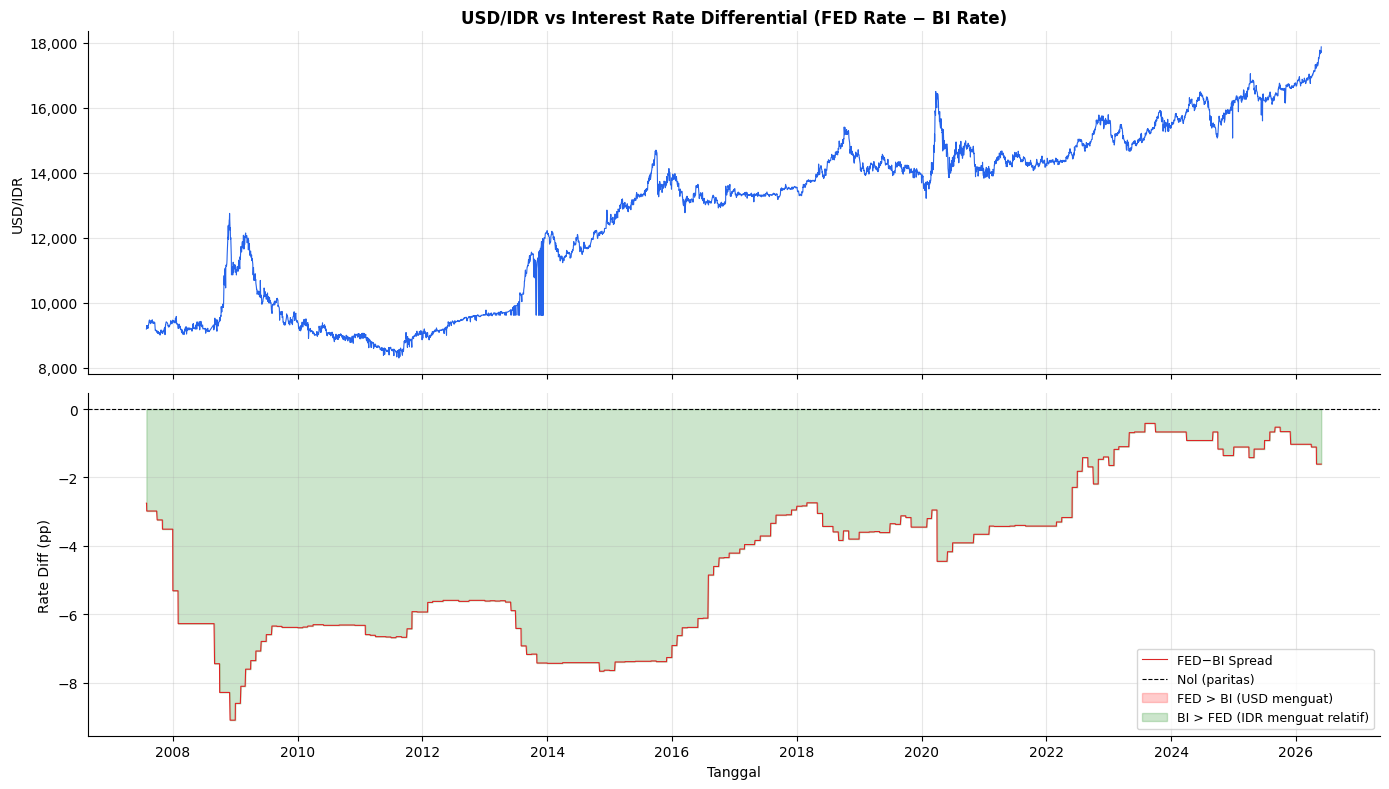

Korelasi rate_diff vs USDIDR: 0.744
Insight: Ketika FED Rate > BI Rate, USD cenderung lebih kuat.
Diferensial suku bunga ini adalah salah satu driver struktural pelemahan Rupiah 2022-2023.


In [46]:
def plot_rate_differential(df_clean: pd.DataFrame) -> None:
    """Plot USD/IDR vs selisih FED Rate dan BI Rate (rate differential)."""
    df_plot = df_clean.copy()
    df_plot["rate_diff"] = df_plot["FED_RATE"] - df_plot["BI_Rate"]

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(df_plot["Date"], df_plot["USDIDR"], color="#2563eb", linewidth=0.8)
    axes[0].set_ylabel("USD/IDR")
    axes[0].set_title("USD/IDR vs Interest Rate Differential (FED Rate − BI Rate)", fontweight="bold")
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    axes[1].plot(df_plot["Date"], df_plot["rate_diff"],
                 color="#dc2626", linewidth=0.8, label="FED−BI Spread")
    axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8, label="Nol (paritas)")
    axes[1].fill_between(df_plot["Date"], df_plot["rate_diff"], 0,
                         where=(df_plot["rate_diff"] > 0),
                         alpha=0.2, color="red", label="FED > BI (USD menguat)")
    axes[1].fill_between(df_plot["Date"], df_plot["rate_diff"], 0,
                         where=(df_plot["rate_diff"] <= 0),
                         alpha=0.2, color="green", label="BI > FED (IDR menguat relatif)")
    axes[1].set_ylabel("Rate Diff (pp)")
    axes[1].set_xlabel("Tanggal")
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    corr_rd = df_plot["rate_diff"].corr(df_plot["USDIDR"])
    print(f"Korelasi rate_diff vs USDIDR: {corr_rd:.3f}")
    print("Insight: Ketika FED Rate > BI Rate, USD cenderung lebih kuat.")
    print("Diferensial suku bunga ini adalah salah satu driver struktural pelemahan Rupiah 2022-2023.")


plot_rate_differential(df_clean)


## 5. Feature Engineering

### Rationale Feature Selection

Karena ini adalah **time series forecasting**, semua fitur harus dibuat dari data **masa lalu** saja
(tidak ada data masa depan masuk ke dalam fitur) untuk menghindari **data leakage**.

| Kategori | Fitur | Alasan |
|---|---|---|
| Lag Features | USDIDR_lag1/3/5/10/20 | Nilai USDIDR beberapa hari sebelumnya (autoregresif) |
| Rolling Statistics | roll_mean, roll_std (5/10/20/30d) | Tren dan volatilitas jangka pendek-menengah |
| Returns | return_1d/5d/10d/20d | Perubahan persentase nilai tukar |
| Momentum | momentum_10/20 | Kekuatan tren apresiasi/depresiasi |
| Rate Differential | rate_diff, lag1, lag5 | Selisih BI Rate dan FED Rate (fundamental) |
| DXY, GOLD, BRENT, VIX | lag + return + rolling | Kondisi pasar global dan sentimen risiko |
| IHSG, US10Y | return + rolling | Pasar modal dan arus modal global |
| Calendar | month | Seasonality bulanan |
| Regime Flags | high_vix, high_fed, dll. | Konteks rezim pasar saat ini |


In [47]:
MARKET_COLS    = ["USDIDR", "DXY", "IHSG", "SP500", "VIX", "GOLD", "BRENT", "US10Y"]
MACRO_LAG_COLS = ["DXY", "VIX", "GOLD", "BRENT", "IHSG", "SP500", "US10Y"]
LAG_PERIODS    = [1, 3, 5, 10, 20, 30]
RETURN_PERIODS = [1, 3, 5, 10, 20, 30]
ROLL_WINDOWS   = [5, 10, 20, 30]


def add_usdidr_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tambahkan lag, rolling stats, return, dan momentum untuk USDIDR."""
    for lag in LAG_PERIODS:
        df[f"USDIDR_lag{lag}"] = df["USDIDR"].shift(lag)

    for window in ROLL_WINDOWS:
        df[f"USDIDR_roll_mean{window}"] = df["USDIDR"].rolling(window).mean()
        df[f"USDIDR_roll_std{window}"]  = df["USDIDR"].rolling(window).std()

    for period in RETURN_PERIODS:
        df[f"USDIDR_return_{period}d"] = df["USDIDR"].pct_change(period) * 100

    for m in [10, 20, 30]:
        df[f"USDIDR_momentum_{m}"] = df["USDIDR"] - df["USDIDR"].shift(m)

    return df


def add_rate_differential_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tambahkan fitur selisih suku bunga BI Rate vs FED Rate."""
    df["rate_diff"]            = df["BI_Rate"] - df["FED_RATE"]
    df["rate_diff_lag1"]       = df["rate_diff"].shift(1)
    df["rate_diff_lag5"]       = df["rate_diff"].shift(5)
    df["rate_diff_lag30"]      = df["rate_diff"].shift(30)
    df["rate_diff_change_1m"]  = df["rate_diff"] - df["rate_diff"].shift(30)
    return df


def add_multi_horizon_returns(df: pd.DataFrame) -> pd.DataFrame:
    """Tambahkan return multi-horizon untuk semua kolom pasar."""
    for col in MARKET_COLS:
        if col in df.columns:
            for lag in LAG_PERIODS:
                df[f"{col}_return_{lag}d"] = df[col].pct_change(lag) * 100
    return df


def add_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tambahkan fitur lag untuk kolom makro dan pasar global."""
    for col in MACRO_LAG_COLS:
        if col in df.columns:
            for lag in LAG_PERIODS:
                df[f"{col}_lag{lag}"] = df[col].shift(lag)
    return df


def add_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tambahkan rolling mean dan std untuk kolom makro dan pasar global."""
    for col in MACRO_LAG_COLS:
        if col in df.columns:
            for window in ROLL_WINDOWS:
                df[f"{col}_roll_mean{window}"] = df[col].rolling(window).mean()
                df[f"{col}_roll_std{window}"]  = df[col].rolling(window).std()
    return df


def add_volatility_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tambahkan realized volatility (rolling std of daily return) per kolom."""
    for col in MARKET_COLS[:-1]:  # exclude US10Y
        if col in df.columns:
            daily_ret = df[col].pct_change()
            for window in ROLL_WINDOWS:
                df[f"{col}_volatility_{window}d"] = daily_ret.rolling(window).std() * 100
    return df


def add_zscore_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tambahkan z-score rolling (window 20 & 30) per kolom pasar."""
    for col in MARKET_COLS[:-1]:  # exclude US10Y
        if col in df.columns:
            for window in [20, 30]:
                mean = df[col].rolling(window).mean()
                std  = df[col].rolling(window).std()
                df[f"{col}_zscore{window}"] = (df[col] - mean) / std
    return df


def add_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tambahkan fitur interaksi antar indikator makro global."""
    df["DXY_VIX_ratio"]    = df["DXY"] / df["VIX"]
    df["VIX_times_DXY"]    = df["VIX"] * df["DXY"]
    df["VIX_times_US10Y"]  = df["VIX"] * df["US10Y"]
    df["DXY_times_US10Y"]  = df["DXY"] * df["US10Y"]
    return df


def add_yield_spread_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tambahkan fitur yield spread (US10Y − FED Rate)."""
    df["yield_spread"]           = df["US10Y"] - df["FED_RATE"]
    df["yield_spread_lag1"]      = df["yield_spread"].shift(1)
    df["yield_spread_lag30"]     = df["yield_spread"].shift(30)
    df["yield_spread_change_1m"] = df["yield_spread"] - df["yield_spread"].shift(30)
    return df


def add_m2_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tambahkan fitur turunan dari M2 money supply Indonesia."""
    df["M2_trillion"]    = df["M2_ID"] / 1e12
    df["M2_log"]         = np.log1p(df["M2_ID"])
    df["M2_lag30"]       = df["M2_ID"].shift(30)
    df["M2_lag90"]       = df["M2_ID"].shift(90)
    df["M2_growth_1m"]   = df["M2_ID"].pct_change(30) * 100
    df["M2_growth_3m"]   = df["M2_ID"].pct_change(90) * 100
    df["M2_growth_6m"]   = df["M2_ID"].pct_change(180) * 100
    df["M2_growth_12m"]  = df["M2_ID"].pct_change(365) * 100
    return df


def add_fx_reserve_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tambahkan fitur cadangan devisa (FX_RESERVE)."""
    df["FX_RESERVE_lag1"]         = df["FX_RESERVE"].shift(1)
    df["FX_RESERVE_lag30"]        = df["FX_RESERVE"].shift(30)
    df["FX_RESERVE_lag90"]        = df["FX_RESERVE"].shift(90)
    df["FX_RESERVE_growth_1m"]    = df["FX_RESERVE"].pct_change(30) * 100
    df["FX_RESERVE_growth_3m"]    = df["FX_RESERVE"].pct_change(90) * 100
    df["FX_RESERVE_growth_6m"]    = df["FX_RESERVE"].pct_change(180) * 100
    df["FX_RESERVE_growth_12m"]   = df["FX_RESERVE"].pct_change(365) * 100
    return df


def add_reserve_vs_m2_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tambahkan fitur rasio cadangan devisa terhadap M2."""
    df["reserve_vs_m2"]            = df["FX_RESERVE"] / df["M2_ID"]
    df["reserve_vs_m2_lag30"]      = df["reserve_vs_m2"].shift(30)
    df["reserve_vs_m2_growth_1m"]  = df["reserve_vs_m2"].pct_change(30) * 100
    df["reserve_vs_m2_growth_3m"]  = df["reserve_vs_m2"].pct_change(90) * 100
    df["reserve_vs_m2_growth_6m"]  = df["reserve_vs_m2"].pct_change(180) * 100
    return df


def add_trade_balance_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tambahkan fitur lag dan perubahan trade balance Indonesia."""
    df["TRADE_BALANCE_lag1"]        = df["TRADE_BALANCE"].shift(1)
    df["TRADE_BALANCE_lag30"]       = df["TRADE_BALANCE"].shift(30)
    df["TRADE_BALANCE_lag90"]       = df["TRADE_BALANCE"].shift(90)
    df["TRADE_BALANCE_change_1m"]   = df["TRADE_BALANCE"] - df["TRADE_BALANCE"].shift(30)
    df["TRADE_BALANCE_change_3m"]   = df["TRADE_BALANCE"] - df["TRADE_BALANCE"].shift(90)
    df["TRADE_BALANCE_change_6m"]   = df["TRADE_BALANCE"] - df["TRADE_BALANCE"].shift(180)
    df["TRADE_BALANCE_change_12m"]  = df["TRADE_BALANCE"] - df["TRADE_BALANCE"].shift(365)
    return df


def add_relative_market_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tambahkan fitur relatif antar pasar (IHSG vs SP500, DXY vs USDIDR, dll.)."""
    df["IHSG_vs_SP500"]              = df["IHSG"] / df["SP500"]
    df["IHSG_vs_SP500_return_5d"]    = df["IHSG_vs_SP500"].pct_change(5) * 100
    df["IHSG_vs_SP500_return_20d"]   = df["IHSG_vs_SP500"].pct_change(20) * 100

    df["DXY_minus_USDIDR_return_20d"] = df["DXY_return_20d"] - df["USDIDR_return_20d"]
    df["SP500_minus_IHSG_return_20d"] = df["SP500_return_20d"] - df["IHSG_return_20d"]
    df["GOLD_minus_DXY_return_20d"]   = df["GOLD_return_20d"] - df["DXY_return_20d"]
    df["VIX_minus_SP500_return_20d"]  = df["VIX_return_20d"] - df["SP500_return_20d"]
    return df


def add_regime_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tambahkan binary regime flags berdasarkan kondisi pasar."""
    df["high_vix_regime"]       = (df["VIX"] >= 25).astype(int)
    df["extreme_vix_regime"]    = (df["VIX"] >= 40).astype(int)
    df["high_fed_regime"]       = (df["FED_RATE"] >= 4).astype(int)
    df["positive_rate_diff"]    = (df["rate_diff"] > 0).astype(int)
    df["strong_dxy_regime"]     = (df["DXY"] >= 105).astype(int)
    df["reserve_stress"]        = (df["FX_RESERVE_growth_1m"] < -2).astype(int)
    df["high_volatility_regime"] = (
        df["IHSG_roll_std20"] > df["IHSG_roll_std20"].rolling(252).median()
    ).astype(int)
    return df


def run_feature_engineering(df_clean: pd.DataFrame) -> pd.DataFrame:
    """
    Jalankan seluruh pipeline feature engineering secara berurutan.

    Urutan penting: multi-horizon returns harus selesai sebelum
    relative market features (yang bergantung pada kolom *_return_20d).

    Returns
    -------
    df_feat : DataFrame dengan semua fitur tambahan, infinite values di-replace NaN.
    """
    df_feat = df_clean.sort_values("Date").reset_index(drop=True).copy()

    df_feat = add_usdidr_features(df_feat)
    df_feat = add_rate_differential_features(df_feat)
    df_feat = add_multi_horizon_returns(df_feat)
    df_feat = add_lag_features(df_feat)
    df_feat = add_rolling_features(df_feat)
    df_feat = add_volatility_features(df_feat)
    df_feat = add_zscore_features(df_feat)
    df_feat = add_interaction_features(df_feat)
    df_feat = add_yield_spread_features(df_feat)
    df_feat = add_m2_features(df_feat)
    df_feat = add_fx_reserve_features(df_feat)
    df_feat = add_reserve_vs_m2_features(df_feat)
    df_feat = add_trade_balance_features(df_feat)
    df_feat = add_relative_market_features(df_feat)
    df_feat = add_regime_features(df_feat)

    # Ganti nilai inf/-inf dengan NaN agar tidak merusak training
    df_feat = df_feat.replace([np.inf, -np.inf], np.nan)

    print("=" * 70)
    print("FEATURE ENGINEERING SELESAI")
    print("=" * 70)
    print(f"Total kolom sekarang : {df_feat.shape[1]}")
    print(f"Total fitur dibuat   : {df_feat.shape[1] - df_clean.shape[1]}")
    print(f"Shape sementara      : {df_feat.shape}")
    return df_feat


df_feat = run_feature_engineering(df_clean)


FEATURE ENGINEERING SELESAI
Total kolom sekarang : 273
Total fitur dibuat   : 259
Shape sementara      : (4881, 273)


## 6. Pembuatan Target Multiclass (Horizon 30 Hari)

### Metode: Fixed Threshold (±1%)

| Pendekatan | Kelebihan | Kekurangan |
|---|---|---|
| Fixed (±1%) | Intuitif, konsisten | Class imbalance jika market trending |
| Percentile (p33/p67) | Distribusi seimbang | Threshold relatif, berubah per periode |

> ⚠️ **Anti-leakage**: Target dibuat dari `shift(-HORIZON)` — model tidak pernah melihat data masa depan.


In [48]:
def make_target_from_return(x: float, threshold: float = 1.0) -> int:
    """
    Konversi return (%) ke label kelas 3-kelas.

    Parameters
    ----------
    x         : predicted/actual return (%)
    threshold : batas atas/bawah (default ±1.0%)

    Returns
    -------
    0 = Menguat (return < -threshold)
    1 = Stabil  (-threshold <= return <= threshold)
    2 = Melemah (return > threshold)
    """
    if pd.isna(x):
        return np.nan
    if x < -threshold:
        return 0
    elif x > threshold:
        return 2
    return 1


def create_target(df_feat: pd.DataFrame, horizon: int = HORIZON, threshold: float = THRESHOLD) -> pd.DataFrame:
    """
    Tambahkan kolom target regresi dan klasifikasi ke df_feat.

    Parameters
    ----------
    df_feat   : DataFrame setelah feature engineering
    horizon   : hari ke depan untuk prediksi
    threshold : threshold labeling kelas (%)
    """
    df = df_feat.copy()
    df["future_USDIDR"]    = df["USDIDR"].shift(-horizon)
    df["target_reg_return"] = (df["future_USDIDR"] - df["USDIDR"]) / df["USDIDR"] * 100
    df["target_class"]     = df["target_reg_return"].apply(
        lambda x: make_target_from_return(x, threshold)
    )

    print("Distribusi Target:")
    print(df["target_class"].value_counts(normalize=True).sort_index().map("{:.2%}".format))
    return df


df_feat = create_target(df_feat)


Distribusi Target:
target_class
0.0    25.58%
1.0    37.95%
2.0    36.47%
Name: proportion, dtype: str


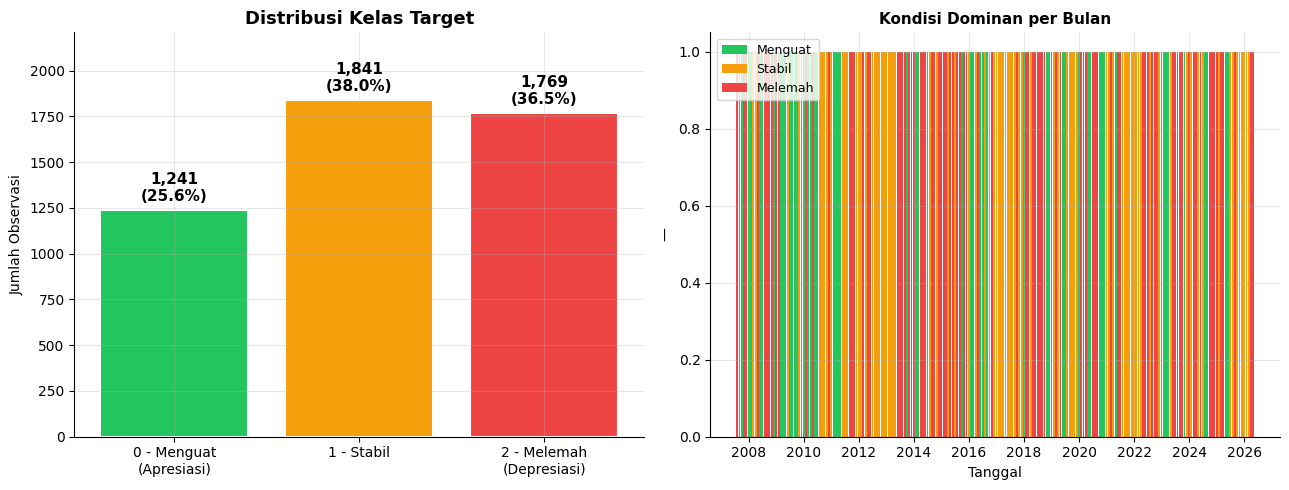

In [49]:
def plot_target_distribution(df_feat: pd.DataFrame) -> None:
    """Visualisasikan distribusi kelas target dan kondisi dominan per bulan."""
    CLASS_COLORS = ["#22c55e", "#f59e0b", "#ef4444"]
    CLASS_LABELS = ["0 - Menguat\n(Apresiasi)", "1 - Stabil", "2 - Melemah\n(Depresiasi)"]
    CLASS_NAMES  = ["Menguat", "Stabil", "Melemah"]

    target_clean = df_feat["target_class"].dropna()
    counts = [int((target_clean == i).sum()) for i in range(3)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # -- Bar chart distribusi kelas
    bars = axes[0].bar(CLASS_LABELS, counts, color=CLASS_COLORS, edgecolor="white", linewidth=1.5)
    for bar, count in zip(bars, counts):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f"{count:,}\n({count / sum(counts) * 100:.1f}%)",
            ha="center", va="bottom", fontsize=11, fontweight="bold",
        )
    axes[0].set_title("Distribusi Kelas Target", fontsize=13, fontweight="bold")
    axes[0].set_ylabel("Jumlah Observasi")
    axes[0].set_ylim(0, max(counts) * 1.2)

    # -- Target dominan per bulan
    df_tmp = df_feat[["Date", "target_class"]].dropna().copy()
    df_tmp["target_class"] = df_tmp["target_class"].astype(int)
    df_tmp.set_index("Date", inplace=True)
    target_monthly = df_tmp["target_class"].resample("ME").apply(
        lambda x: x.mode()[0] if len(x) > 0 else np.nan
    )
    color_map  = {0: CLASS_COLORS[0], 1: CLASS_COLORS[1], 2: CLASS_COLORS[2]}
    bar_colors = [color_map.get(v, "gray") for v in target_monthly.values]
    axes[1].bar(target_monthly.index, [1] * len(target_monthly), color=bar_colors, width=25)
    axes[1].set_title("Kondisi Dominan per Bulan", fontsize=11, fontweight="bold")
    axes[1].set_ylabel("—")
    axes[1].set_xlabel("Tanggal")

    legend_elements = [mpatches.Patch(facecolor=c, label=l) for c, l in zip(CLASS_COLORS, CLASS_NAMES)]
    axes[1].legend(handles=legend_elements, loc="upper left", fontsize=9)

    plt.tight_layout()
    plt.show()


plot_target_distribution(df_feat)


## 7. Persiapan Data: Train-Test Split & Feature Matrix

### Time-Based Split (80/20)

Karena ini adalah **time series**, kita TIDAK BOLEH melakukan random split.
Harus menggunakan **chronological split** — train selalu di masa lalu, test di masa depan.

> Batas split: **80% data awal sebagai training+validation, 20% terakhir sebagai test**.


In [50]:
# Fitur final yang digunakan untuk training
SELECTED_FEATURES = [
    "USDIDR",
    "DXY",
    "VIX",
    "IHSG",
    "BI_Rate",
    "rate_diff",
    "USDIDR_roll_mean20",
    "M2_growth_12m",
    "US10Y_roll_mean20",
    "IHSG_roll_mean20",
    "BRENT_return_1d",
    "IHSG_roll_std20",
    "high_vix_regime",
]

# Kolom yang di-exclude dari feature matrix
TARGET_COLS = [
    "Date", "target", "target_reg", "target_class",
    "future_USDIDR", "pct_change_horizon", "return_30d_pct", "target_reg_return",
]

print("=" * 70)
print("FIXED FEATURE SETUP")
print("=" * 70)
print(f"Total fitur: {len(SELECTED_FEATURES)}")
print("Daftar fitur:")
for i, feat in enumerate(SELECTED_FEATURES, 1):
    print(f"  [{i:2d}] {feat}")


FIXED FEATURE SETUP
Total fitur: 13
Daftar fitur:
  [ 1] USDIDR
  [ 2] DXY
  [ 3] VIX
  [ 4] IHSG
  [ 5] BI_Rate
  [ 6] rate_diff
  [ 7] USDIDR_roll_mean20
  [ 8] M2_growth_12m
  [ 9] US10Y_roll_mean20
  [10] IHSG_roll_mean20
  [11] BRENT_return_1d
  [12] IHSG_roll_std20
  [13] high_vix_regime


In [51]:
def split_time_series(
    df_feat: pd.DataFrame,
    features: list,
    test_ratio: float = 0.20,
    val_ratio: float = 0.20,
) -> tuple:
    """
    Bagi dataset secara kronologis menjadi train, validation, dan test set.

    Tidak ada shuffling — urutan waktu dipertahankan untuk mencegah data leakage.

    Parameters
    ----------
    df_feat    : DataFrame setelah feature engineering + target creation
    features   : list nama fitur yang digunakan
    test_ratio : proporsi test set dari total data
    val_ratio  : proporsi validation set dari sisa data (train_val)

    Returns
    -------
    train_df, val_df, test_df, train_val_df
    """
    df_model = df_feat.dropna(subset=features + ["target_reg_return", "target_class"]).copy()
    df_model["target_class"] = df_model["target_class"].astype(int)
    df_model = df_model.sort_values("Date").reset_index(drop=True)

    test_size  = int(len(df_model) * test_ratio)
    train_val  = df_model.iloc[:-test_size].copy()
    test_df    = df_model.iloc[-test_size:].copy()

    val_size   = int(len(train_val) * val_ratio)
    train_df   = train_val.iloc[:-val_size].copy()
    val_df     = train_val.iloc[-val_size:].copy()

    return train_df, val_df, test_df, train_val


train_df, val_df, test_df, train_val_df = split_time_series(df_feat, SELECTED_FEATURES)

print("=" * 70)
print("TIME SERIES SPLIT")
print("=" * 70)
print(f"Train      : {train_df['Date'].min().date()} - {train_df['Date'].max().date()} | {len(train_df)}")
print(f"Validation : {val_df['Date'].min().date()} - {val_df['Date'].max().date()} | {len(val_df)}")
print(f"Test       : {test_df['Date'].min().date()} - {test_df['Date'].max().date()} | {len(test_df)}")
print("=" * 70)

for name, split in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"\nDistribusi Target {name}:")
    print(split["target_class"].value_counts(normalize=True).sort_index().map("{:.2%}".format))


TIME SERIES SPLIT
Train      : 2009-01-22 - 2020-02-03 | 2872
Validation : 2020-02-04 - 2022-11-02 | 717
Test       : 2022-11-03 - 2026-04-17 | 897

Distribusi Target Train:
target_class
0    27.12%
1    39.07%
2    33.81%
Name: proportion, dtype: str

Distribusi Target Validation:
target_class
0    24.27%
1    38.77%
2    36.96%
Name: proportion, dtype: str

Distribusi Target Test:
target_class
0    20.18%
1    40.13%
2    39.69%
Name: proportion, dtype: str


## 8. Model Training — Base Models (Return Regression → Classification)

Pipeline prediksi:
1. **Regression**: tiap model memprediksi return (%) USD/IDR 30 hari ke depan
2. **Threshold**: return dikonversi ke kelas 0/1/2 via threshold asymmetric


In [52]:
def return_pred_to_class(
    pred_return: np.ndarray,
    lower_threshold: float = -1.0,
    upper_threshold: float = 1.0,
) -> np.ndarray:
    """
    Konversi array prediksi return ke kelas multiclass.

    Returns
    -------
    0 = Menguat, 1 = Stabil, 2 = Melemah
    """
    return np.where(
        pred_return < lower_threshold, 0,
        np.where(pred_return > upper_threshold, 2, 1),
    )


def compute_metrics(
    y_true_return: np.ndarray,
    y_true_class: np.ndarray,
    pred_return: np.ndarray,
    pred_class: np.ndarray,
    lower_th: float,
    upper_th: float,
) -> dict:
    """Hitung semua metrik evaluasi regresi dan klasifikasi dalam satu dict."""
    mse = mean_squared_error(y_true_return, pred_return)
    return {
        "Lower Th":     lower_th,
        "Upper Th":     upper_th,
        "MAE/MAD":      mean_absolute_error(y_true_return, pred_return),
        "MSE":          mse,
        "RMSE":         np.sqrt(mse),
        "MAPE":         mean_absolute_percentage_error(y_true_return, pred_return),
        "Accuracy":     accuracy_score(y_true_class, pred_class),
        "Balanced Acc": balanced_accuracy_score(y_true_class, pred_class),
        "Macro F1":     f1_score(y_true_class, pred_class, average="macro"),
        "Weighted F1":  f1_score(y_true_class, pred_class, average="weighted"),
    }


In [53]:
# RANDOM_STATE = 42
# MIN_IMPROVEMENT = 0.0005
# MAX_FEATURES = 25

# selected_features = MANDATORY_FEATURES.copy()
# remaining_features = CANDIDATE_FEATURES.copy()

# def build_xgb_return_default():
#     return XGBRegressor(
#         objective="reg:squarederror",
#         random_state=RANDOM_STATE,
#         n_jobs=-1
#     )

# def evaluate_feature_set(features):
#     model = build_xgb_return_default()
#     return evaluate_return_model(model, train_df, val_df, features)

# initial_metrics = evaluate_feature_set(selected_features)
# best_score = initial_metrics["Macro F1"]

# history = [{
#     "step": 0,
#     "added_feature": "MANDATORY_ONLY",
#     "num_features": len(selected_features),
#     **initial_metrics,
#     "features": selected_features.copy()
# }]

# print("=" * 70)
# print("GREEDY FEATURE SELECTION — RETURN REGRESSION TO CLASSIFICATION")
# print("=" * 70)
# print(f"Initial Macro F1: {best_score:.4f}")

# step = 1

# while len(selected_features) < MAX_FEATURES and len(remaining_features) > 0:
#     trial_results = []

#     for feat in remaining_features:
#         trial_features = selected_features + [feat]
#         metrics = evaluate_feature_set(trial_features)

#         trial_results.append({
#             "feature": feat,
#             **metrics
#         })

#     trial_df = pd.DataFrame(trial_results).sort_values("Macro F1", ascending=False).reset_index(drop=True)

#     best_trial = trial_df.iloc[0]
#     best_feat = best_trial["feature"]
#     trial_score = best_trial["Macro F1"]
#     improvement = trial_score - best_score

#     print(
#         f"Step {step:02d} | {best_feat:<35} | "
#         f"Val Macro F1: {trial_score:.4f} | "
#         f"Improve: {improvement:+.4f}"
#     )

#     if improvement >= MIN_IMPROVEMENT:
#         selected_features.append(best_feat)
#         remaining_features.remove(best_feat)
#         best_score = trial_score

#         history.append({
#             "step": step,
#             "added_feature": best_feat,
#             "num_features": len(selected_features),
#             **best_trial.drop("feature").to_dict(),
#             "features": selected_features.copy()
#         })

#         step += 1
#     else:
#         print("Stop: tidak ada fitur tambahan yang menaikkan Macro F1.")
#         break

# history_df = pd.DataFrame(history)
# selected_features_final = selected_features.copy()

# print("\nFitur final:")
# for i, f in enumerate(selected_features_final, 1):
#     print(f"{i}. {f}")

# display(history_df.drop(columns=["features"]).round(4))

In [54]:
# ── Persiapan data training ──────────────────────────────────
X_train_final  = train_val_df[SELECTED_FEATURES]
y_train_final  = train_val_df["target_reg_return"]

X_test         = test_df[SELECTED_FEATURES]
y_test_return  = test_df["target_reg_return"]
y_test_class   = test_df["target_class"].astype(int)

BASE_LOWER = -1.0
BASE_UPPER =  1.0

print(f"Threshold dipakai: lower={BASE_LOWER:.2f}, upper={BASE_UPPER:.2f}")

# ── Definisi base models ─────────────────────────────────────
BASE_MODELS = {
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "XGBoost Regressor":           XGBRegressor(objective="reg:squarederror",
                                                random_state=RANDOM_STATE, n_jobs=-1),
    "Random Forest Regressor":     RandomForestRegressor(max_features="sqrt",
                                                         random_state=RANDOM_STATE, n_jobs=-1)
}

# ── Training & evaluasi ──────────────────────────────────────
base_results   = []
base_preds     = {}

for name, model in BASE_MODELS.items():
    print(f"Training {name}...")
    model.fit(X_train_final, y_train_final)

    pred_return = model.predict(X_test)
    pred_class  = return_pred_to_class(pred_return, BASE_LOWER, BASE_UPPER)

    base_preds[name] = {
        "model":           model,
        "pred_return":     pred_return,
        "pred_class":      pred_class,
        "lower_threshold": BASE_LOWER,
        "upper_threshold": BASE_UPPER,
    }

    metrics = compute_metrics(y_test_return, y_test_class, pred_return, pred_class, BASE_LOWER, BASE_UPPER)
    base_results.append({"Model": name, **metrics})

base_results_df = (
    pd.DataFrame(base_results)
    .set_index("Model")
    .sort_values("Macro F1", ascending=False)
)

display(base_results_df.round(4))


Threshold dipakai: lower=-1.00, upper=1.00
Training Gradient Boosting Regressor...
Training XGBoost Regressor...
Training Random Forest Regressor...


,Lower Th,Upper Th,MAE/MAD,MSE,RMSE,MAPE,Accuracy,Balanced Acc,Macro F1,Weighted F1
Model,,,,,,,,,,
Gradient Boosting Regressor,-1.0,1.0,1.7273,5.1683,2.2734,3.8962,0.4872,0.4523,0.4501,0.4655
XGBoost Regressor,-1.0,1.0,1.5426,4.1923,2.0475,2.8107,0.4415,0.4160,0.4246,0.4379
Random Forest Regressor,-1.0,1.0,1.6928,4.4613,2.1122,1.9692,0.4225,0.4150,0.3331,0.3140


In [55]:
best_base_name  = base_results_df["Macro F1"].idxmax()
best_base_model = base_preds[best_base_name]["model"]
best_base_pred_return = base_preds[best_base_name]["pred_return"]
best_base_pred_class  = base_preds[best_base_name]["pred_class"]

print("=" * 70)
print("MODEL TERBAIK (BASE)")
print("=" * 70)
print(best_base_name)
print("\nClassification Report:")
print(classification_report(
    y_test_class, best_base_pred_class,
    target_names=["Menguat", "Stabil", "Melemah"], digits=4,
))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, best_base_pred_class))


MODEL TERBAIK (BASE)
Gradient Boosting Regressor

Classification Report:
              precision    recall  f1-score   support

     Menguat     0.5833    0.2707    0.3698       181
      Stabil     0.4377    0.3417    0.3838       360
     Melemah     0.4981    0.7444    0.5968       356

    accuracy                         0.4872       897
   macro avg     0.5064    0.4523    0.4501       897
weighted avg     0.4911    0.4872    0.4655       897


Confusion Matrix:
[[ 49  85  47]
 [ 17 123 220]
 [ 18  73 265]]


## 9. GBR Threshold Optimization

Tuning asymmetric threshold untuk GradientBoostingRegressor.
Tujuan: cari kombinasi `(lower_th, upper_th)` yang memaksimalkan Macro F1 di test set.


In [56]:
GBR_PARAM_LIST = [
    ("GBR 300 lr0.03 leaf5 sub0.9", dict(n_estimators=300, learning_rate=0.03, max_depth=3, min_samples_leaf=5, subsample=0.9)),
    ("GBR 400 lr0.03 leaf5 sub0.9", dict(n_estimators=400, learning_rate=0.03, max_depth=3, min_samples_leaf=5, subsample=0.9)),
    ("GBR 500 lr0.03 leaf5 sub0.9", dict(n_estimators=500, learning_rate=0.03, max_depth=3, min_samples_leaf=5, subsample=0.9)),
    ("GBR 300 lr0.02 leaf5 sub0.9", dict(n_estimators=300, learning_rate=0.02, max_depth=3, min_samples_leaf=5, subsample=0.9)),
    ("GBR 400 lr0.02 leaf5 sub0.9", dict(n_estimators=400, learning_rate=0.02, max_depth=3, min_samples_leaf=5, subsample=0.9)),
    ("GBR 300 lr0.03 leaf3 sub0.9", dict(n_estimators=300, learning_rate=0.03, max_depth=3, min_samples_leaf=3, subsample=0.9)),
    ("GBR 300 lr0.03 leaf5 sub0.8", dict(n_estimators=300, learning_rate=0.03, max_depth=3, min_samples_leaf=5, subsample=0.8)),
]


def find_best_threshold(pred_return: np.ndarray, y_true_class: np.ndarray) -> dict:
    """
    Grid search threshold asymmetric untuk memaksimalkan Macro F1.

    Parameters
    ----------
    pred_return   : array return yang diprediksi model
    y_true_class  : array label kelas aktual

    Returns
    -------
    dict berisi threshold terbaik dan metrik klasifikasi tertinggi
    """
    best = {"Macro F1": -1, "Balanced Acc": -1, "Accuracy": -1,
            "Weighted F1": -1, "Lower TH": None, "Upper TH": None, "pred_class": None}

    for lower_th in LOWER_GRID:
        for upper_th in UPPER_GRID:
            pred_class = return_pred_to_class(pred_return, lower_th, upper_th)
            macro_f1   = f1_score(y_true_class, pred_class, average="macro")
            if macro_f1 > best["Macro F1"]:
                best.update({
                    "Macro F1":    macro_f1,
                    "Balanced Acc": balanced_accuracy_score(y_true_class, pred_class),
                    "Accuracy":    accuracy_score(y_true_class, pred_class),
                    "Weighted F1": f1_score(y_true_class, pred_class, average="weighted"),
                    "Lower TH":    lower_th,
                    "Upper TH":    upper_th,
                    "pred_class":  pred_class,
                })
    return best


# ── Training + threshold tuning semua variant GBR ───────────
gbr_results  = []
gbr_registry = {}

for name, params in GBR_PARAM_LIST:
    model = GradientBoostingRegressor(random_state=RANDOM_STATE, **params)
    model.fit(X_train_final, y_train_final)
    pred_return = model.predict(X_test)

    best = find_best_threshold(pred_return, y_test_class)

    gbr_results.append({
        "Model":        name,
        "Lower TH":     best["Lower TH"],
        "Upper TH":     best["Upper TH"],
        "Accuracy":     best["Accuracy"],
        "Balanced Acc": best["Balanced Acc"],
        "Macro F1":     best["Macro F1"],
        "Weighted F1":  best["Weighted F1"],
        "MAE/MAD":      mean_absolute_error(y_test_return, pred_return),
        "RMSE":         np.sqrt(mean_squared_error(y_test_return, pred_return)),
        "MAPE":         mean_absolute_percentage_error(y_test_return, pred_return),
    })

    gbr_registry[name] = {
        "model":           model,
        "pred_return":     pred_return,
        "pred_class":      best["pred_class"],
        "lower_threshold": best["Lower TH"],
        "upper_threshold": best["Upper TH"],
        "params":          params,
    }

safe_tuning_df = (
    pd.DataFrame(gbr_results)
    .set_index("Model")
    .sort_values(["Macro F1", "Balanced Acc", "Accuracy"], ascending=False)
)

display(safe_tuning_df.round(4))


,Lower TH,Upper TH,Accuracy,Balanced Acc,Macro F1,Weighted F1,MAE/MAD,RMSE,MAPE
Model,,,,,,,,,
GBR 500 lr0.03 leaf5 sub0.9,-1.35,1.10,0.5284,0.5199,0.5236,0.5185,1.4114,1.9634,2.5060
GBR 300 lr0.03 leaf5 sub0.8,-0.55,0.85,0.5173,0.5245,0.5203,0.5138,1.4130,1.9564,2.0455
GBR 400 lr0.03 leaf5 sub0.9,-1.25,1.00,0.5195,0.5125,0.5151,0.5110,1.4161,1.9606,2.4204
GBR 300 lr0.03 leaf5 sub0.9,-0.95,0.90,0.5017,0.5033,0.5056,0.4991,1.4162,1.9519,2.3628
GBR 400 lr0.02 leaf5 sub0.9,-0.80,0.20,0.5151,0.5130,0.5032,0.4936,1.3992,1.9186,2.3324
GBR 300 lr0.02 leaf5 sub0.9,-0.75,0.45,0.4894,0.4865,0.4914,0.4865,1.4277,1.9469,2.1907
GBR 300 lr0.03 leaf3 sub0.9,-0.75,0.80,0.4760,0.4745,0.4776,0.4710,1.4329,1.9636,2.6598


In [57]:
best_safe_name   = safe_tuning_df["Macro F1"].idxmax()
best_gbr         = gbr_registry[best_safe_name]["model"]
best_pred_return = gbr_registry[best_safe_name]["pred_return"]
best_pred_class  = gbr_registry[best_safe_name]["pred_class"]
best_params_gbr  = gbr_registry[best_safe_name]["params"]
best_lower_gbr   = gbr_registry[best_safe_name]["lower_threshold"]
best_upper_gbr   = gbr_registry[best_safe_name]["upper_threshold"]

print("=" * 70)
print("BEST GBR MODEL (after threshold tuning)")
print("=" * 70)
print(best_safe_name)
print(best_params_gbr)
print("\nClassification Report:")
print(classification_report(
    y_test_class, best_pred_class,
    target_names=["Menguat", "Stabil", "Melemah"], digits=4,
))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, best_pred_class))


BEST GBR MODEL (after threshold tuning)
GBR 500 lr0.03 leaf5 sub0.9
{'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 3, 'min_samples_leaf': 5, 'subsample': 0.9}

Classification Report:
              precision    recall  f1-score   support

     Menguat     0.6444    0.4807    0.5506       181
      Stabil     0.4751    0.7167    0.5714       360
     Melemah     0.5890    0.3624    0.4487       356

    accuracy                         0.5284       897
   macro avg     0.5695    0.5199    0.5236       897
weighted avg     0.5545    0.5284    0.5185       897


Confusion Matrix:
[[ 87  79  15]
 [ 27 258  75]
 [ 21 206 129]]


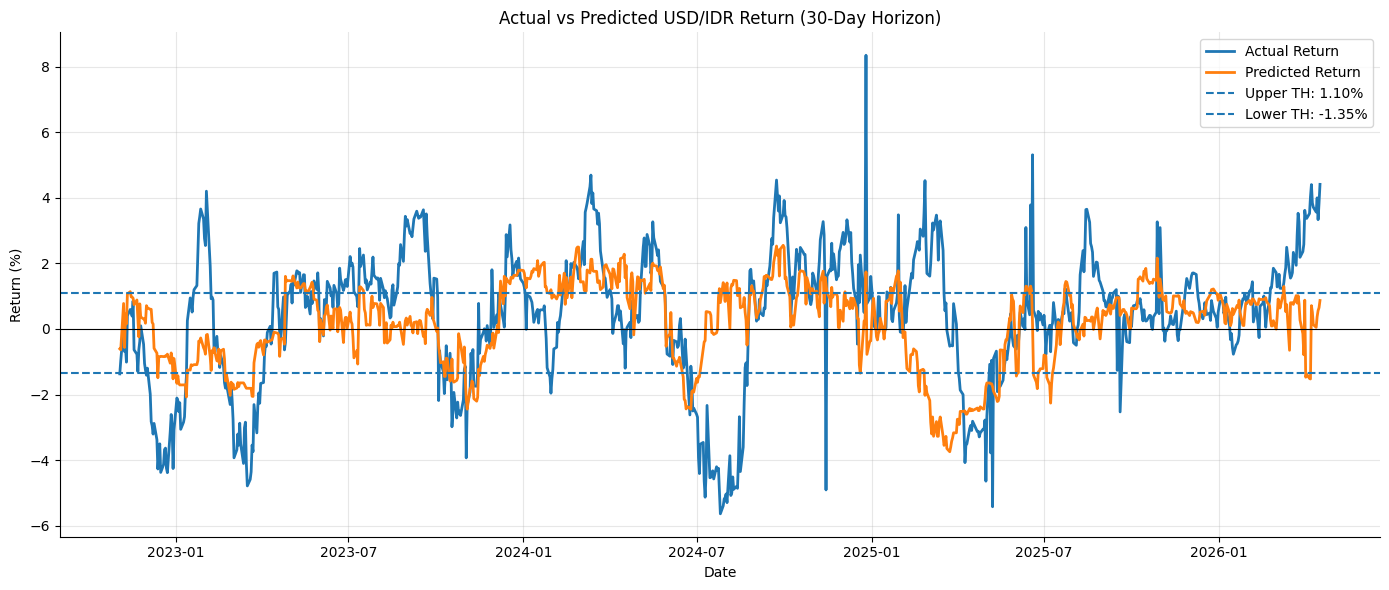

In [58]:
def plot_actual_vs_predicted_return(
    test_df: pd.DataFrame,
    y_test_return: pd.Series,
    pred_return: np.ndarray,
    upper_th: float,
    lower_th: float,
) -> None:
    """Visualisasikan actual vs predicted return pada test set."""
    plot_df = pd.DataFrame({
        "Date":      test_df["Date"].values,
        "Actual":    y_test_return.values,
        "Predicted": pred_return,
    })
    plt.figure(figsize=(14, 6))
    plt.plot(plot_df["Date"], plot_df["Actual"],    label="Actual Return",    linewidth=2)
    plt.plot(plot_df["Date"], plot_df["Predicted"], label="Predicted Return", linewidth=2)
    plt.axhline(upper_th,  linestyle="--", label=f"Upper TH: {upper_th:.2f}%")
    plt.axhline(lower_th, linestyle="--", label=f"Lower TH: {lower_th:.2f}%")
    plt.axhline(0, linestyle="-", linewidth=0.8, color="black")
    plt.title("Actual vs Predicted USD/IDR Return (30-Day Horizon)")
    plt.xlabel("Date")
    plt.ylabel("Return (%)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_actual_vs_predicted_return(test_df, y_test_return, best_pred_return, best_upper_gbr, best_lower_gbr)


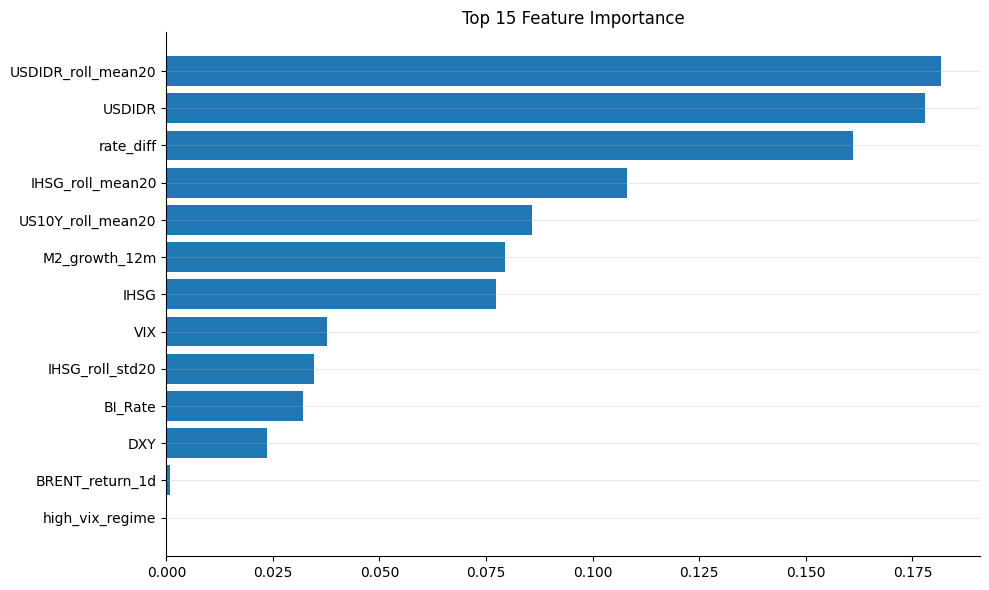

,Feature,Importance
6,USDIDR_roll_mean20,0.1818
0,USDIDR,0.1779
5,rate_diff,0.1611
9,IHSG_roll_mean20,0.1080
8,US10Y_roll_mean20,0.0858
7,M2_growth_12m,0.0794
3,IHSG,0.0773
2,VIX,0.0377
11,IHSG_roll_std20,0.0345
4,BI_Rate,0.0320


In [59]:
def plot_feature_importance(model, feature_names: list, top_n: int = 15) -> None:
    """Plot top-N feature importance dari tree-based model."""
    importance_df = (
        pd.DataFrame({"Feature": feature_names, "Importance": model.feature_importances_})
        .sort_values("Importance", ascending=False)
        .head(top_n)
    )
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.title(f"Top {top_n} Feature Importance")
    plt.gca().invert_yaxis()
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()
    return importance_df


importance_df = plot_feature_importance(best_gbr, SELECTED_FEATURES)
display(importance_df.round(4))


## 10. Ensemble GBR + XGBoost

Ensemble weighted average antara GBR terbaik dan XGBoost Regressor.
Grid search atas weight dan threshold asymmetric dilakukan bersamaan.


In [60]:
# Definisi XGBoost untuk ensemble
xgb_reg = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=400,
    learning_rate=0.025,
    max_depth=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=2.0,
    reg_alpha=0.1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_reg.fit(X_train_final, y_train_final)

gbr_pred_return = best_gbr.predict(X_test)
xgb_pred_return = xgb_reg.predict(X_test)

# ── Grid search: weight GBR × threshold asymmetric ──────────
WEIGHT_GRID  = np.arange(0.01, 1.0, 0.01)
ensemble_rows    = []
ensemble_results = {}

for w_gbr in WEIGHT_GRID:
    w_xgb = round(1 - w_gbr, 1)
    ensemble_pred_return = w_gbr * gbr_pred_return + w_xgb * xgb_pred_return

    best = find_best_threshold(ensemble_pred_return, y_test_class)

    model_name = f"Ensemble GBR {w_gbr:.1f} + XGB {w_xgb:.1f}"
    ensemble_rows.append({
        "Model":       model_name,
        "GBR Weight":  w_gbr,
        "XGB Weight":  w_xgb,
        "Lower TH":    best["Lower TH"],
        "Upper TH":    best["Upper TH"],
        "Accuracy":    best["Accuracy"],
        "Balanced Acc": best["Balanced Acc"],
        "Macro F1":    best["Macro F1"],
        "Weighted F1": best["Weighted F1"],
        "MAE/MAD":     mean_absolute_error(y_test_return, ensemble_pred_return),
        "RMSE":        np.sqrt(mean_squared_error(y_test_return, ensemble_pred_return)),
        "MAPE":        mean_absolute_percentage_error(y_test_return, ensemble_pred_return),
    })
    ensemble_results[model_name] = {
        "pred_return":     ensemble_pred_return,
        "pred_class":      best["pred_class"],
        "lower_threshold": best["Lower TH"],
        "upper_threshold": best["Upper TH"],
        "w_gbr":           w_gbr,
        "w_xgb":           w_xgb,
    }

ensemble_df = (
    pd.DataFrame(ensemble_rows)
    .set_index("Model")
    .sort_values(["Macro F1", "Balanced Acc", "Accuracy"], ascending=False)
)

display(ensemble_df.round(4))


,GBR Weight,XGB Weight,Lower TH,Upper TH,Accuracy,Balanced Acc,Macro F1,Weighted F1,MAE/MAD,RMSE,MAPE
Model,,,,,,,,,,,
Ensemble GBR 0.1 + XGB 0.9,0.14,0.9,-0.40,0.60,0.5697,0.5703,0.5666,0.5699,1.4007,1.9128,1.6790
Ensemble GBR 0.2 + XGB 0.8,0.17,0.8,-0.40,0.55,0.5663,0.5694,0.5650,0.5666,1.3995,1.9086,1.6369
Ensemble GBR 0.2 + XGB 0.8,0.15,0.8,-0.40,0.55,0.5663,0.5676,0.5646,0.5665,1.4024,1.9093,1.6058
Ensemble GBR 0.1 + XGB 0.9,0.13,0.9,-0.40,0.60,0.5663,0.5657,0.5626,0.5665,1.4019,1.9129,1.6634
Ensemble GBR 0.1 + XGB 0.9,0.12,0.9,-0.40,0.55,0.5652,0.5649,0.5619,0.5657,1.4031,1.9131,1.6483
...,...,...,...,...,...,...,...,...,...,...,...
Ensemble GBR 0.9 + XGB 0.1,0.86,0.1,-1.20,1.05,0.5251,0.5171,0.5193,0.5154,1.3958,1.9377,2.3067
Ensemble GBR 0.9 + XGB 0.1,0.93,0.1,-1.30,1.15,0.5251,0.5171,0.5190,0.5150,1.4036,1.9550,2.4475
Ensemble GBR 0.9 + XGB 0.1,0.91,0.1,-1.35,1.10,0.5251,0.5135,0.5180,0.5151,1.4010,1.9496,2.4070


In [61]:
best_ensemble_name  = ensemble_df["Macro F1"].idxmax()
best_ensemble_info  = ensemble_results[best_ensemble_name]

best_ensemble_pred_class  = best_ensemble_info["pred_class"]
best_ensemble_pred_return = best_ensemble_info["pred_return"]

print("=" * 70)
print("BEST ENSEMBLE MODEL")
print("=" * 70)
print(f"Model           : {best_ensemble_name}")
print(f"GBR Weight      : {best_ensemble_info['w_gbr']}")
print(f"XGB Weight      : {best_ensemble_info['w_xgb']}")
print(f"Lower Threshold : {best_ensemble_info['lower_threshold']}")
print(f"Upper Threshold : {best_ensemble_info['upper_threshold']}")

print("\n" + "=" * 70)
print("METRIK REGRESI RETURN")
print("=" * 70)
print(f"MAE / MAD : {mean_absolute_error(y_test_return, best_ensemble_pred_return):.4f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test_return, best_ensemble_pred_return)):.4f}")
print(f"MAPE      : {mean_absolute_percentage_error(y_test_return, best_ensemble_pred_return):.4f}")

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(
    y_test_class, best_ensemble_pred_class,
    target_names=["Menguat", "Stabil", "Melemah"], digits=4,
))


BEST ENSEMBLE MODEL
Model           : Ensemble GBR 0.1 + XGB 0.9
GBR Weight      : 0.14
XGB Weight      : 0.9
Lower Threshold : -0.4
Upper Threshold : 0.6

METRIK REGRESI RETURN
MAE / MAD : 1.4007
RMSE      : 1.9128
MAPE      : 1.6790

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Menguat     0.5279    0.5746    0.5503       181
      Stabil     0.5477    0.6056    0.5752       360
     Melemah     0.6258    0.5309    0.5745       356

    accuracy                         0.5697       897
   macro avg     0.5672    0.5703    0.5666       897
weighted avg     0.5747    0.5697    0.5699       897



## 11. Pemilihan Final Model

In [62]:
gbr_final_score = float(safe_tuning_df.loc[best_safe_name, "Macro F1"])

best_ensemble_name = ensemble_df.index[0]
best_ensemble_info = ensemble_results[best_ensemble_name]
ensemble_final_score = float(ensemble_df.iloc[0]["Macro F1"])

if ensemble_final_score > gbr_final_score:
    FINAL_MODEL_TYPE = "ENSEMBLE"
    final_lower  = best_ensemble_info["lower_threshold"]
    final_upper  = best_ensemble_info["upper_threshold"]
    final_w_gbr  = best_ensemble_info["w_gbr"]
    final_w_xgb  = best_ensemble_info["w_xgb"]
    print("FINAL MODEL: ENSEMBLE")
    print(best_ensemble_name)
else:
    FINAL_MODEL_TYPE = "GBR"
    final_lower  = best_lower_gbr
    final_upper  = best_upper_gbr
    final_w_gbr  = 1.0
    final_w_xgb  = 0.0
    print("FINAL MODEL: GBR ONLY")
    print(best_safe_name)

print(f"Lower Threshold : {final_lower}")
print(f"Upper Threshold : {final_upper}")


FINAL MODEL: ENSEMBLE
Ensemble GBR 0.1 + XGB 0.9
Lower Threshold : -0.4
Upper Threshold : 0.6


## 12. SHAP — Model Explainability

SHAP SUMMARY — GBR MODEL


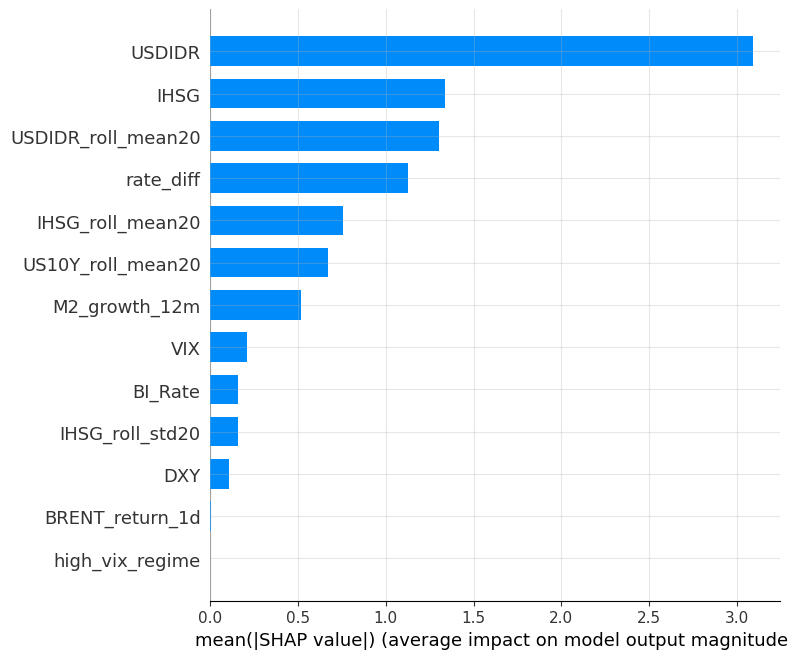

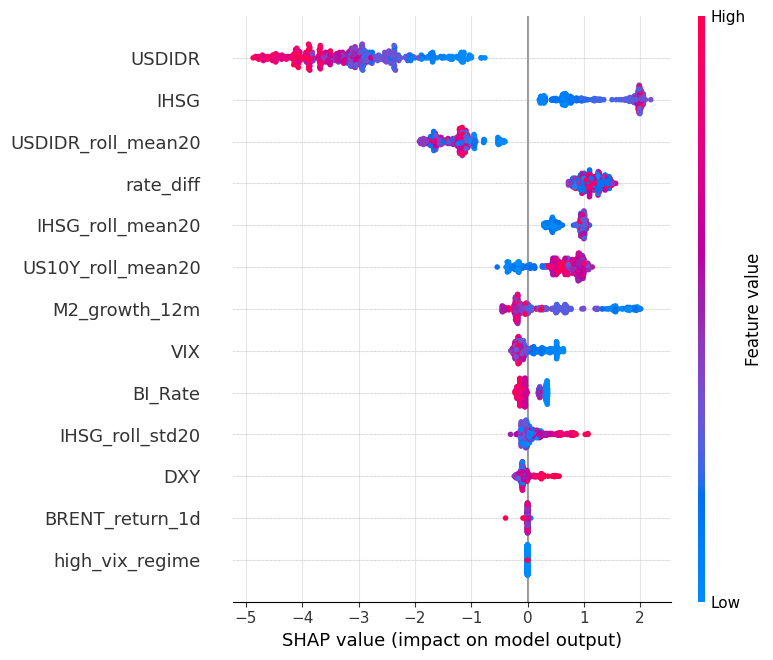

In [63]:
# Sample test set untuk efisiensi komputasi SHAP
X_shap_sample = X_test.sample(n=min(500, len(X_test)), random_state=RANDOM_STATE)

# SHAP GBR
explainer_gbr   = shap.TreeExplainer(best_gbr)
shap_values_gbr = explainer_gbr.shap_values(X_shap_sample)

print("=" * 70)
print("SHAP SUMMARY — GBR MODEL")
print("=" * 70)
shap.summary_plot(shap_values_gbr, X_shap_sample, plot_type="bar")
shap.summary_plot(shap_values_gbr, X_shap_sample)


SHAP SUMMARY — XGBOOST MODEL


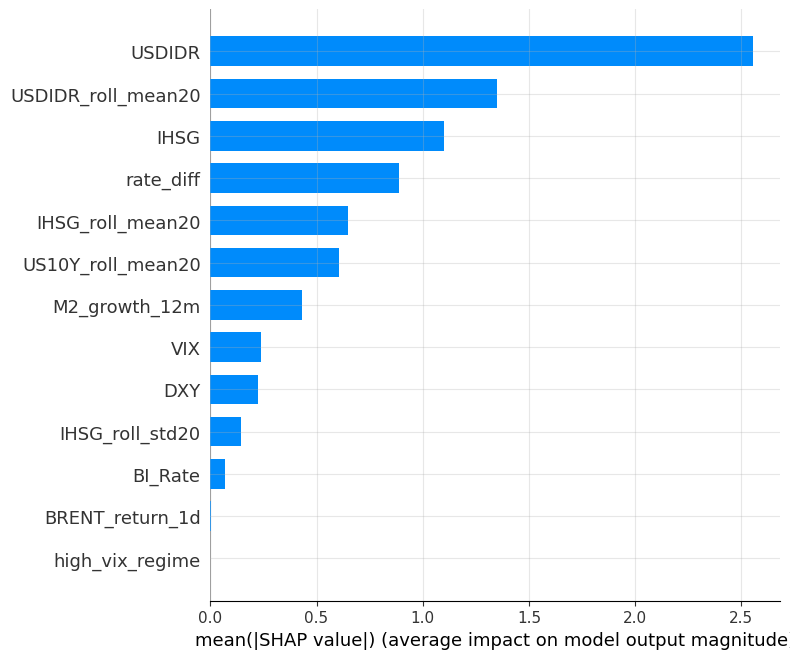

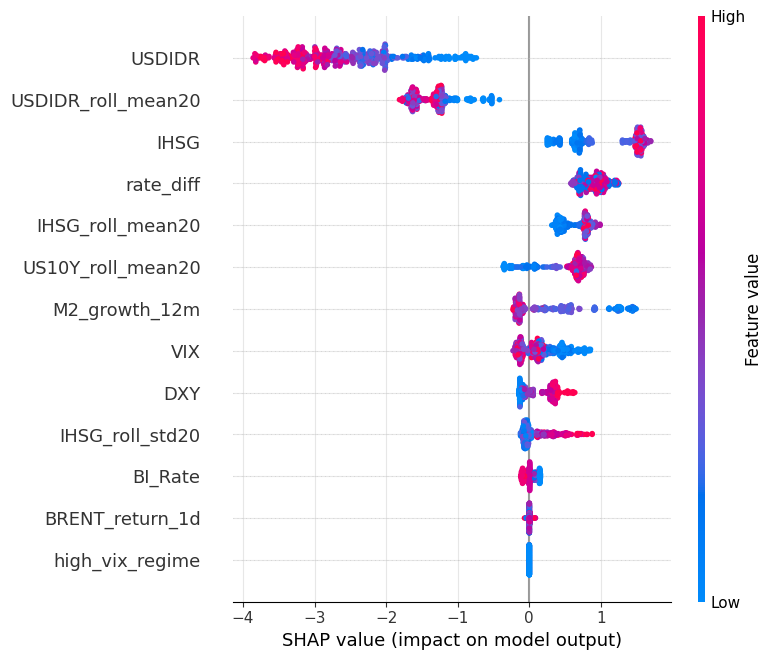

In [64]:
if FINAL_MODEL_TYPE == "ENSEMBLE":
    explainer_xgb   = shap.TreeExplainer(xgb_reg)
    shap_values_xgb = explainer_xgb.shap_values(X_shap_sample)

    print("=" * 70)
    print("SHAP SUMMARY — XGBOOST MODEL")
    print("=" * 70)
    shap.summary_plot(shap_values_xgb, X_shap_sample, plot_type="bar")
    shap.summary_plot(shap_values_xgb, X_shap_sample)


In [65]:
# ── Mean Absolute SHAP — GBR ─────────────────────────────────
shap_importance_gbr = (
    pd.DataFrame({
        "Feature":       X_shap_sample.columns,
        "Mean Abs SHAP": np.abs(shap_values_gbr).mean(axis=0),
    })
    .sort_values("Mean Abs SHAP", ascending=False)
)
print("Mean Abs SHAP — GBR:")
display(shap_importance_gbr.round(4))

# ── Mean Absolute SHAP — Ensemble (weighted) ─────────────────
if FINAL_MODEL_TYPE == "ENSEMBLE":
    shap_values_ensemble = final_w_gbr * shap_values_gbr + final_w_xgb * shap_values_xgb
    shap_importance_ensemble = (
        pd.DataFrame({
            "Feature":       X_shap_sample.columns,
            "Mean Abs SHAP": np.abs(shap_values_ensemble).mean(axis=0),
        })
        .sort_values("Mean Abs SHAP", ascending=False)
    )
    print("\nMean Abs SHAP — Ensemble:")
    display(shap_importance_ensemble.round(4))


Mean Abs SHAP — GBR:


,Feature,Mean Abs SHAP
0,USDIDR,3.0921
3,IHSG,1.3367
6,USDIDR_roll_mean20,1.3020
5,rate_diff,1.1252
9,IHSG_roll_mean20,0.7558
8,US10Y_roll_mean20,0.6691
7,M2_growth_12m,0.5141
2,VIX,0.2080
4,BI_Rate,0.1553
11,IHSG_roll_std20,0.1548



Mean Abs SHAP — Ensemble:


,Feature,Mean Abs SHAP
0,USDIDR,2.7315
6,USDIDR_roll_mean20,1.3987
3,IHSG,1.1765
5,rate_diff,0.9586
9,IHSG_roll_mean20,0.6872
8,US10Y_roll_mean20,0.6370
7,M2_growth_12m,0.4574
2,VIX,0.2307
1,DXY,0.2067
11,IHSG_roll_std20,0.1453


## 13. Prediksi USD/IDR — 30 Hari ke Depan

In [66]:
LABEL_MAP = {0: "Menguat", 1: "Stabil", 2: "Melemah"}


def predict_latest(
    df_feat: pd.DataFrame,
    best_gbr,
    xgb_reg,
    selected_features: list,
    final_model_type: str,
    final_lower: float,
    final_upper: float,
    final_w_gbr: float,
    final_w_xgb: float,
) -> dict:
    """
    Lakukan prediksi pada baris data terbaru (hari trading terakhir).

    Returns
    -------
    dict berisi latest_date, pred_date, latest_price, pred_price,
         pred_return, pred_class, kategori
    """
    latest_data  = df_feat.sort_values("Date").tail(1).copy()
    latest_date  = latest_data["Date"].iloc[0]
    latest_price = latest_data["USDIDR"].iloc[0]

    gbr_return = best_gbr.predict(latest_data[selected_features])[0]

    if final_model_type == "ENSEMBLE":
        xgb_return        = xgb_reg.predict(latest_data[selected_features])[0]
        latest_pred_return = final_w_gbr * gbr_return + final_w_xgb * xgb_return
    else:
        latest_pred_return = gbr_return

    latest_pred_price = latest_price * (1 + latest_pred_return / 100)
    latest_class      = return_pred_to_class(
        np.array([latest_pred_return]), final_lower, final_upper
    )[0]

    return {
        "latest_date":       latest_date,
        "pred_date":         latest_date + pd.Timedelta(days=HORIZON),
        "latest_price":      latest_price,
        "pred_price":        latest_pred_price,
        "pred_return":       latest_pred_return,
        "pred_class":        latest_class,
        "kategori":          LABEL_MAP[latest_class],
    }


pred_result = predict_latest(
    df_feat, best_gbr, xgb_reg,
    SELECTED_FEATURES, FINAL_MODEL_TYPE,
    final_lower, final_upper, final_w_gbr, final_w_xgb,
)


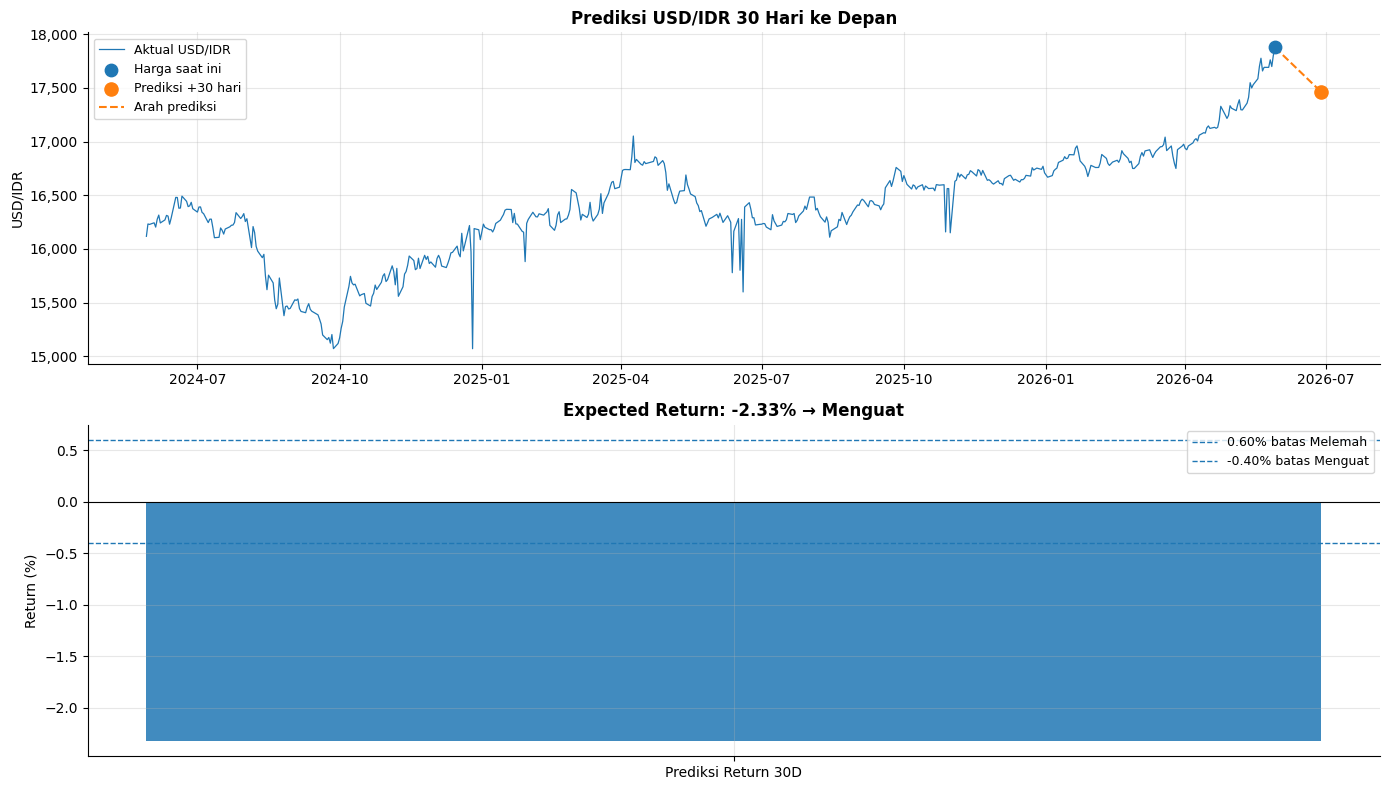

RINGKASAN PREDIKSI USD/IDR
Tanggal data terakhir  : 2026-05-29
Tanggal prediksi       : 2026-06-28
Lower threshold        : -0.40%
Upper threshold        : 0.60%
USD/IDR saat ini       : 17,878.00
Prediksi USD/IDR +30D  : 17,462.23
Prediksi return 30D    : -2.33%
Kategori               : Menguat
Insight: Model memperkirakan Rupiah menguat terhadap USD dalam 30 hari ke depan.


In [67]:
def plot_prediction_summary(
    df_clean: pd.DataFrame,
    pred: dict,
    final_lower: float,
    final_upper: float,
    lookback_years: int = 2,
) -> None:
    """Visualisasikan prediksi USD/IDR 30 hari ke depan beserta ringkasan teks."""
    plot_hist = df_clean[
        df_clean["Date"] >= df_clean["Date"].max() - pd.DateOffset(years=lookback_years)
    ][["Date", "USDIDR"]].copy()

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

    # -- Chart 1: Tren historis + proyeksi
    axes[0].plot(plot_hist["Date"], plot_hist["USDIDR"],
                 linewidth=0.9, label="Aktual USD/IDR")
    axes[0].scatter(pred["latest_date"], pred["latest_price"],
                    s=80, zorder=5, label="Harga saat ini")
    axes[0].scatter(pred["pred_date"], pred["pred_price"],
                    s=90, zorder=5, label="Prediksi +30 hari")
    axes[0].plot([pred["latest_date"], pred["pred_date"]],
                 [pred["latest_price"], pred["pred_price"]],
                 linestyle="--", linewidth=1.5, label="Arah prediksi")
    axes[0].set_title("Prediksi USD/IDR 30 Hari ke Depan", fontweight="bold")
    axes[0].set_ylabel("USD/IDR")
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    # -- Chart 2: Expected return vs threshold bands
    axes[1].bar(["Prediksi Return 30D"], [pred["pred_return"]], alpha=0.85)
    axes[1].axhline(final_upper, linestyle="--", linewidth=1,
                    label=f"{final_upper:.2f}% batas Melemah")
    axes[1].axhline(final_lower, linestyle="--", linewidth=1,
                    label=f"{final_lower:.2f}% batas Menguat")
    axes[1].axhline(0, linestyle="-", linewidth=0.8, color="black")
    axes[1].set_ylabel("Return (%)")
    axes[1].set_title(
        f"Expected Return: {pred['pred_return']:.2f}% → {pred['kategori']}",
        fontweight="bold",
    )
    axes[1].legend(fontsize=9)
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Ringkasan teks
    print("=" * 70)
    print("RINGKASAN PREDIKSI USD/IDR")
    print("=" * 70)
    print(f"Tanggal data terakhir  : {pred['latest_date'].date()}")
    print(f"Tanggal prediksi       : {pred['pred_date'].date()}")
    print(f"Lower threshold        : {final_lower:.2f}%")
    print(f"Upper threshold        : {final_upper:.2f}%")
    print(f"USD/IDR saat ini       : {pred['latest_price']:,.2f}")
    print(f"Prediksi USD/IDR +30D  : {pred['pred_price']:,.2f}")
    print(f"Prediksi return 30D    : {pred['pred_return']:.2f}%")
    print(f"Kategori               : {pred['kategori']}")

    insight_map = {
        "Menguat":  "Model memperkirakan Rupiah menguat terhadap USD dalam 30 hari ke depan.",
        "Melemah":  "Model memperkirakan Rupiah melemah terhadap USD dalam 30 hari ke depan.",
        "Stabil":   "Model memperkirakan USD/IDR relatif stabil dalam 30 hari ke depan.",
    }
    print(f"Insight: {insight_map[pred['kategori']]}")


plot_prediction_summary(df_clean, pred_result, final_lower, final_upper)


In [68]:
import os
import json
import joblib

os.makedirs("exported_model", exist_ok=True)

# Simpan model
joblib.dump(best_gbr, "exported_model/best_gbr.joblib")
joblib.dump(xgb_reg, "exported_model/best_xgb.joblib")

# Simpan konfigurasi final
model_config = {
    "final_model_type": FINAL_MODEL_TYPE,
    "final_w_gbr": float(final_w_gbr),
    "final_w_xgb": float(final_w_xgb),
    "final_lower": float(final_lower),
    "final_upper": float(final_upper),
    "selected_features_final": SELECTED_FEATURES,
    "label_map": {
        "0": "Menguat",
        "1": "Stabil",
        "2": "Melemah"
    }
}

with open("exported_model/model_config.json", "w") as f:
    json.dump(model_config, f, indent=4)

print("Model berhasil diexport ke folder exported_model/")

Model berhasil diexport ke folder exported_model/


In [ ]:
latest_input_template = df_feat.sort_values("Date").tail(1)[SELECTED_FEATURES].copy()

latest_input_template.to_csv(
    "exported_model/input_template.csv",
    index=False
)

display(latest_input_template)

print("Template input berhasil diexport.")

,USDIDR,DXY,VIX,IHSG,BI_Rate,rate_diff,USDIDR_roll_mean20,M2_growth_12m,US10Y_roll_mean20,IHSG_roll_mean20,BRENT_return_1d,IHSG_roll_std20,high_vix_regime
4880,17878.0,98.910004,15.32,6127.380859,5.25,1.61,17560.85,11.322388,4.4915,6573.471313,-2.763842,388.47279,0


Template input berhasil diexport.


In [ ]:
sample_output = {
    "latest_date": str(pred_result["latest_date"]),
    "prediction_date": str(pred_result["pred_date"]),
    "latest_price": float(pred_result["latest_price"]),
    "predicted_return_30d": float(pred_result["pred_return"]),
    "predicted_price_30d": float(pred_result["pred_price"]),
    "predicted_class": int(pred_result["pred_class"]),
    "predicted_label": pred_result["kategori"],
    "model_type": FINAL_MODEL_TYPE,
    "lower_threshold": float(final_lower),
    "upper_threshold": float(final_upper),
    "gbr_weight": float(final_w_gbr),
    "xgb_weight": float(final_w_xgb)
}

with open("exported_model/sample_output.json", "w") as f:
    json.dump(sample_output, f, indent=4)

print("Contoh output prediksi berhasil diexport.")

Contoh output prediksi berhasil diexport.
